# F4 - Consolidação final dos resultados

Este notebook executa a **Fase 4 (F4)** da pesquisa. Sua função é integrar, conferir e comparar os resultados produzidos pelas estratégias F3-A, F3-B, F3-C, F3-D e F3-E e pela etapa complementar de autocorreção final.

A F4 não realiza novas inferências e não altera nenhuma saída produzida na F3. Ela trabalha somente com os registros já congelados, preservando a rastreabilidade entre estratégia, fold, exemplo, método de seleção, valor de `k`, variante e tentativa de autocorreção.

A cadeia consolidada é:

```text
F3-A: NL → Nile
F3-B: NL → Nile + primeira autocorreção
F3-C: NL → IR → Nile, sem AC e com primeira AC
F3-D: NL + R3 → Nile, sem AC e com primeira AC
F3-E: NL + R1 → IR; IR + R2 → Nile, sem AC e com primeira AC
Autocorreção final: segunda tentativa aplicada às saídas ainda inválidas de F3-B/C/D/E
                              ↓
auditoria dos pacotes e da cadeia de resultados
                              ↓
consolidação dos estados experimentais
                              ↓
comparações descritivas e pareadas
                              ↓
análise por estratégia, método, k, fold e exemplo
                              ↓
gráficos finais padronizados
                              ↓
f4_consolidacao_resultados.zip
```

A análise distingue três perspectivas principais:

| Perspectiva | Estados comparados | Finalidade |
|---|---|---|
| Estratégias principais | F3-A, F3-B, F3-C, F3-D e F3-E após a primeira AC | Comparação principal entre as cinco estratégias |
| Artefatos sem autocorreção | F3-A, F3-C, F3-D e F3-E na variante `sem_ac` | Isolar o efeito da IR e das justificativas |
| Resultado após AC final | F3-A e estados finais de F3-B/C/D/E | Medir o efeito acumulado da autocorreção iterativa |

As comparações principais utilizam apenas as condições few-shot comuns:

```text
k = 1, 3 e 5
Aleatória, Lexical e Semântica
50 exemplos
5 folds
450 registros por estado
```

O zero-shot de F3-A e F3-B é preservado e analisado separadamente, pois F3-C, F3-D e F3-E não possuem `k=0`.

O notebook está organizado em dez blocos:

| Bloco | Etapa | Resultado principal |
|---:|---|---|
| 1 | Configuração geral | Caminhos, funções, métricas, estados e padrões visuais |
| 2 | Localização e auditoria | Pacotes oficiais identificados e arquivos obrigatórios conferidos |
| 3 | Carga e padronização | Doze estados experimentais integrados em uma estrutura comum |
| 4 | Consistência da cadeia | Continuidade entre tradução, primeira AC e AC final confirmada |
| 5 | Visões analíticas | Conjuntos comparáveis e contrastes planejados definidos |
| 6 | Consolidação descritiva | Resumos por estado, método, k, fold e condição |
| 7 | Análise estatística | Contrastes pareados, intervalos de confiança e correção de Holm |
| 8 | Custo e análise por exemplo | Custos, estabilidade, exemplos fáceis e difíceis |
| 9 | Gráficos finais | 10 gráficos no padrão visual da F4 anterior, com dimensões e escalas padronizadas |
| 10 | Empacotamento | Barreiras finais, manifesto, hashes e ZIP da F4 |

### Escopo métrico final

A consolidação utiliza exclusivamente as seis métricas oficiais:

```text
PSR, EM, ED, NED, SLA-S e SLA-F
```

Indicadores auxiliares das fases anteriores não são tratados como métricas da F4.

## Bloco 1 - Configuração geral

### Objetivo

Este bloco fixa o escopo da consolidação, os estados experimentais, as seis métricas oficiais, as comparações planejadas, os diretórios de trabalho e as funções comuns de leitura, escrita, exibição, hashing e padronização gráfica.

### Estados experimentais

A F4 não cria novas estratégias. Os códigos internos representam momentos já existentes da execução:

```text
A0: F3-A sem autocorreção
B1: F3-B após a primeira autocorreção
C0/C1: F3-C sem AC e após a primeira AC
D0/D1: F3-D sem AC e após a primeira AC
E0/E1: F3-E sem AC e após a primeira AC
B2/C2/D2/E2: resultados após a autocorreção final
```

### Métricas oficiais

A F4 utiliza exclusivamente:

```text
PSR, EM, ED, NED, SLA-S e SLA-F
```

Nenhum indicador complementar é tratado como métrica da F4.

### Estatística

Os contrastes planejados são pareados pela mesma combinação de exemplo, fold, método e `k`.

São utilizados:

- teste de postos sinalizados de Wilcoxon sobre as diferenças médias por exemplo nas seis métricas;
- intervalo de confiança por bootstrap pareado no nível do exemplo;
- correção de Holm para comparações múltiplas;
- contagens descritivas das transições binárias de PSR, EM e SLA-S, sem aplicação de teste inferencial sobre os 450 registros.

### Resultado esperado

O bloco não gera resultados experimentais. Ele apenas prepara a infraestrutura determinística da F4.

In [1]:
# ----------------------------------------------------------
# 1.1 Importação das bibliotecas principais
# ----------------------------------------------------------

import gzip
import hashlib
import importlib.metadata
import io
import json
import math
import os
import platform
import re
import shutil
import sys
import warnings
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display
from PIL import Image, ImageOps
from scipy.stats import rankdata, wilcoxon


# ----------------------------------------------------------
# 1.2 Identificação da fase e parâmetros fixos
# ----------------------------------------------------------

FASE = "F4"
NOME_ETAPA = "Consolidação final dos resultados experimentais"
DATASET = "CAMPI"
SEED_GLOBAL = 42
BOOTSTRAP_REPETICOES = 5000
ALPHA = 0.05

WILCOXON_ZERO_METHOD = "wilcox"
WILCOXON_ALTERNATIVE = "two-sided"
WILCOXON_METHOD = "auto"
BOOTSTRAP_CI_METHOD = "percentile"
BOOTSTRAP_CI_QUANTILES = (
    ALPHA / 2,
    1 - ALPHA / 2,
)

TOTAL_EXEMPLOS_ESPERADO = 50
TOTAL_FOLDS_ESPERADO = 5
TOTAL_ESTADOS_ESPERADO = 12
TOTAL_REGISTROS_ESTADOS_ESPERADO = 5550
TOTAL_REGISTROS_MAIN_ESPERADO = 2250
TOTAL_REGISTROS_SEM_AC_ESPERADO = 1800
TOTAL_REGISTROS_FINAL_ESPERADO = 2250
TOTAL_GRAFICOS_ESPERADO = 11
CONTADOR_TABELAS = 0

METRICAS = ["psr", "em", "ed", "ned", "sla_s", "sla_f"]
METRICAS_BINARIAS = ["psr", "em", "sla_s"]
ROTULOS_METRICAS = {
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}
METRICAS_MENOR_MELHOR = {"ed", "ned"}

METODO_ZERO_SHOT = "zero_shot"
METODOS_FEWSHOT = [
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]
ORDEM_METODOS_EXIBICAO = [METODO_ZERO_SHOT, *METODOS_FEWSHOT]
ORDEM_METODOS_MAPA = {
    metodo: posicao
    for posicao, metodo in enumerate(ORDEM_METODOS_EXIBICAO)
}
ROTULOS_METODOS = {
    METODO_ZERO_SHOT: "Nenhum (zero-shot)",
    "random_seed42": "Aleatória",
    "lexical_tfidf": "Lexical",
    "semantic_embeddings": "Semântica",
}

ESTADOS = {
    "A0": {
        "strategy": "F3-A",
        "variant": "sem_ac",
        "label": "F3-A",
        "stage": "sem_ac",
        "family": "Direta",
        "expected_records": 500,
    },
    "B1": {
        "strategy": "F3-B",
        "variant": "primeira_ac",
        "label": "F3-B",
        "stage": "primeira_ac",
        "family": "Direta",
        "expected_records": 500,
    },
    "C0": {
        "strategy": "F3-C",
        "variant": "sem_ac",
        "label": "F3-C sem AC",
        "stage": "sem_ac",
        "family": "F3-C",
        "expected_records": 450,
    },
    "C1": {
        "strategy": "F3-C",
        "variant": "primeira_ac",
        "label": "F3-C",
        "stage": "primeira_ac",
        "family": "F3-C",
        "expected_records": 450,
    },
    "D0": {
        "strategy": "F3-D",
        "variant": "sem_ac",
        "label": "F3-D sem AC",
        "stage": "sem_ac",
        "family": "F3-D",
        "expected_records": 450,
    },
    "D1": {
        "strategy": "F3-D",
        "variant": "primeira_ac",
        "label": "F3-D",
        "stage": "primeira_ac",
        "family": "F3-D",
        "expected_records": 450,
    },
    "E0": {
        "strategy": "F3-E",
        "variant": "sem_ac",
        "label": "F3-E sem AC",
        "stage": "sem_ac",
        "family": "F3-E",
        "expected_records": 450,
    },
    "E1": {
        "strategy": "F3-E",
        "variant": "primeira_ac",
        "label": "F3-E",
        "stage": "primeira_ac",
        "family": "F3-E",
        "expected_records": 450,
    },
    "B2": {
        "strategy": "F3-B",
        "variant": "autocorrecao_final",
        "label": "F3-B + AC final",
        "stage": "autocorrecao_final",
        "family": "Direta",
        "expected_records": 500,
    },
    "C2": {
        "strategy": "F3-C",
        "variant": "autocorrecao_final",
        "label": "F3-C + AC final",
        "stage": "autocorrecao_final",
        "family": "F3-C",
        "expected_records": 450,
    },
    "D2": {
        "strategy": "F3-D",
        "variant": "autocorrecao_final",
        "label": "F3-D + AC final",
        "stage": "autocorrecao_final",
        "family": "F3-D",
        "expected_records": 450,
    },
    "E2": {
        "strategy": "F3-E",
        "variant": "autocorrecao_final",
        "label": "F3-E + AC final",
        "stage": "autocorrecao_final",
        "family": "F3-E",
        "expected_records": 450,
    },
}
ORDEM_ESTADOS = list(ESTADOS)
ORDEM_ESTADOS_MAPA = {
    estado: posicao
    for posicao, estado in enumerate(ORDEM_ESTADOS)
}

CORES_ESTRATEGIAS = {
    "F3-A": "#4D4D4D",
    "F3-B": "#6A3D9A",
    "F3-C": "#1F77B4",
    "F3-D": "#2CA02C",
    "F3-E": "#F28E2B",
}
CORES_ESTAGIOS = {
    "sem_ac": "#1F77B4",
    "primeira_ac": "#6A3D9A",
    "autocorrecao_final": "#F28E2B",
}


# ----------------------------------------------------------
# 1.3 Pacotes de entrada e arquivos obrigatórios
# ----------------------------------------------------------

FONTES = {
    "F3-A": {
        "phase": "F3-A",
        "result_file": "f3a_results.csv",
        "expected_records": 500,
    },
    "F3-B": {
        "phase": "F3-B",
        "result_file": "f3b_results.csv",
        "expected_records": 500,
    },
    "F3-C": {
        "phase": "F3-C",
        "result_file": "f3c_results.csv",
        "expected_records": 900,
    },
    "F3-D": {
        "phase": "F3-D",
        "result_file": "f3d_results.csv",
        "expected_records": 900,
    },
    "F3-E": {
        "phase": "F3-E",
        "result_file": "f3e_results.csv",
        "expected_records": 900,
    },
    "AC-final": {
        "phase": "F3-autocorrecao-final",
        "result_file": "f3_autocorrecao_final_results.csv",
        "comparison_file": "f3_autocorrecao_final_comparison.csv",
        "expected_records": 1850,
    },
}


# ----------------------------------------------------------
# 1.4 Diretórios de trabalho
# ----------------------------------------------------------

KAGGLE_INPUT = Path("/kaggle/input")
RAIZ_TRABALHO = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path("/mnt/data/f4_consolidacao_working")
)

F4_DIR = RAIZ_TRABALHO / "f4_consolidacao"
ENTRADAS_DIR = F4_DIR / "entradas"
GRAFICOS_DIR = F4_DIR / "graficos"
PACOTE_DIR = F4_DIR / "pacote"
CACHE_DIR = F4_DIR / "cache_fontes"

for diretorio in [
    F4_DIR,
    ENTRADAS_DIR,
    GRAFICOS_DIR,
    PACOTE_DIR,
    CACHE_DIR,
]:
    diretorio.mkdir(parents=True, exist_ok=True)

ZIP_FINAL_PATH = RAIZ_TRABALHO / "f4_consolidacao_resultados.zip"
MANIFEST_PATH = PACOTE_DIR / "manifest.json"


# ----------------------------------------------------------
# 1.4.1 Manifesto mestre da entrega
# ----------------------------------------------------------

MANIFESTO_MESTRE_JSON_PATH = (
    PACOTE_DIR
    / "manifesto_mestre_entrega.json"
)
MANIFESTO_MESTRE_CSV_PATH = (
    PACOTE_DIR
    / "manifesto_mestre_entrega.csv"
)
ZIP_SHA256_PATH = (
    RAIZ_TRABALHO
    / f"{ZIP_FINAL_PATH.name}.sha256"
)

REPOSITORIO_TRABALHO = (
    "https://github.com/CypherGuedes/"
    "Traducao-NL-Nile-Modelo-Compacto"
)

# No Kaggle, os notebooks que originaram as fases não são
# montados automaticamente como arquivos .ipynb. Por isso,
# eles são registrados como referências do repositório.
NOTEBOOKS_MESTRE = [
    {
        "ordem": 1,
        "fase": "F0",
        "nome": "f0-preparacao-base.ipynb",
    },
    {
        "ordem": 2,
        "fase": "F1",
        "nome": "f1-preparacao-ir.ipynb",
    },
    {
        "ordem": 3,
        "fase": "F2",
        "nome": "f2-preparacao-r1-r2-r3.ipynb",
    },
    {
        "ordem": 4,
        "fase": "F3-modelo",
        "nome": "f3-modelo.ipynb",
    },
    {
        "ordem": 5,
        "fase": "F3-A",
        "nome": "f3a-estrategia-a.ipynb",
    },
    {
        "ordem": 6,
        "fase": "F3-B",
        "nome": "f3b-estrategia-b.ipynb",
    },
    {
        "ordem": 7,
        "fase": "F3-C",
        "nome": "f3c-estrategia-c.ipynb",
    },
    {
        "ordem": 8,
        "fase": "F3-D",
        "nome": "f3d-estrategia-d.ipynb",
    },
    {
        "ordem": 9,
        "fase": "F3-E",
        "nome": "f3e-estrategia-e.ipynb",
    },
    {
        "ordem": 10,
        "fase": "F3-AC-final",
        "nome": "f3-autocorrecao-final.ipynb",
    },
    {
        "ordem": 11,
        "fase": "F4",
        "nome": "f4-resultados.ipynb",
    },
]

# Os pacotes anteriores aparecem em /kaggle/input como
# diretórios de datasets, e não como arquivos ZIP.
PACOTES_MESTRE_ANTERIORES = [
    {
        "ordem": 1,
        "fase": "F0",
        "nome": "f0_operacional.zip",
        "dataset_aliases": [
            "f0_operacional",
            "f0-operacional",
        ],
    },
    {
        "ordem": 2,
        "fase": "F1",
        "nome": "f1_operacional.zip",
        "dataset_aliases": [
            "f1_operacional",
            "f1-operacional",
        ],
    },
    {
        "ordem": 3,
        "fase": "F2",
        "nome": "f2_operacional.zip",
        "dataset_aliases": [
            "f2_operacional",
            "f2-operacional",
        ],
    },
    {
        "ordem": 4,
        "fase": "F3-modelo",
        "nome": "f3_modelo_operacional.zip",
        "dataset_aliases": [
            "f3_modelo_operacional",
            "f3-modelo-operacional",
        ],
    },
    {
        "ordem": 5,
        "fase": "F3-A",
        "nome": "f3a_traducao_direta.zip",
        "dataset_aliases": [
            "f3a_traducao_direta",
            "f3a-traducao-direta",
        ],
    },
    {
        "ordem": 6,
        "fase": "F3-B",
        "nome": "f3b_autocorrecao_traducao_direta.zip",
        "dataset_aliases": [
            "f3b_autocorrecao_traducao_direta",
            "f3b-autocorrecao-traducao-direta",
        ],
    },
    {
        "ordem": 7,
        "fase": "F3-C",
        "nome": "f3c_traducao_com_ir.zip",
        "dataset_aliases": [
            "f3c_traducao_com_ir",
            "f3c-traducao-com-ir",
        ],
    },
    {
        "ordem": 8,
        "fase": "F3-D",
        "nome": "f3d_traducao_com_r3.zip",
        "dataset_aliases": [
            "f3d_traducao_com_r3",
            "f3d-traducao-com-r3",
        ],
    },
    {
        "ordem": 9,
        "fase": "F3-E",
        "nome": "f3e_traducao_com_r1_r2.zip",
        "dataset_aliases": [
            "f3e_traducao_com_r1_r2",
            "f3e-traducao-com-r1-r2",
        ],
    },
    {
        "ordem": 10,
        "fase": "F3-AC-final",
        "nome": "f3_autocorrecao_final.zip",
        "dataset_aliases": [
            "f3_autocorrecao_final",
            "f3-autocorrecao-final",
        ],
    },
]

ARTEFATOS_ENTREGA_RAIZES = [
    KAGGLE_INPUT,
    RAIZ_TRABALHO / "artefatos_entrega",
]


ARQUIVOS_SAIDA = {
    "config": PACOTE_DIR / "f4_config.json",
    "input_audit": PACOTE_DIR / "f4_input_audit.csv",
    "chain_audit": PACOTE_DIR / "f4_chain_audit.csv",
    "state_inventory": PACOTE_DIR / "f4_state_inventory.csv",
    "all_states": PACOTE_DIR / "f4_all_states.jsonl.gz",
    "main_records": PACOTE_DIR / "f4_main_comparison_records.csv",
    "sem_ac_records": PACOTE_DIR / "f4_sem_ac_comparison_records.csv",
    "final_records": PACOTE_DIR / "f4_final_comparison_records.csv",
    "zero_shot": PACOTE_DIR / "f4_zero_shot.csv",
    "summary_state": PACOTE_DIR / "f4_summary_by_state.csv",
    "summary_method_k": PACOTE_DIR / "f4_summary_by_method_k.csv",
    "summary_fold": PACOTE_DIR / "f4_summary_by_fold.csv",
    "fold_stability": PACOTE_DIR / "f4_fold_stability.csv",
    "planned_contrasts": PACOTE_DIR / "f4_planned_contrasts.csv",
    "binary_transitions": PACOTE_DIR / "f4_binary_transitions.csv",
    "best_conditions": PACOTE_DIR / "f4_best_conditions.csv",
    "cost_summary": PACOTE_DIR / "f4_cost_summary.csv",
    "autocorrection_timeline": PACOTE_DIR / "f4_autocorrection_timeline.csv",
    "analysis_example": PACOTE_DIR / "f4_analysis_by_example.csv",
    "graph_inventory": PACOTE_DIR / "f4_graph_inventory.csv",
}


# ----------------------------------------------------------
# 1.5 Funções de serialização e hashing
# ----------------------------------------------------------

def canonical_json(data):
    return json.dumps(
        data,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_bytes(data):
    return hashlib.sha256(data).hexdigest()


def _esta_dentro(caminho, raiz):
    caminho = Path(caminho).resolve()
    raiz = Path(raiz).resolve()
    try:
        caminho.relative_to(raiz)
        return True
    except ValueError:
        return False


def normalizar_nome_dataset(nome):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(nome).lower(),
    )


def localizar_dataset_entrega(especificacao):
    aliases_normalizados = {
        normalizar_nome_dataset(alias)
        for alias in especificacao["dataset_aliases"]
    }

    candidatos = []
    for raiz in ARTEFATOS_ENTREGA_RAIZES:
        raiz = Path(raiz)
        if not raiz.exists():
            continue

        diretorios = [
            raiz,
            *[
                caminho
                for caminho in raiz.rglob("*")
                if caminho.is_dir()
            ],
        ]

        for caminho in diretorios:
            if _esta_dentro(caminho, F4_DIR):
                continue
            if (
                normalizar_nome_dataset(caminho.name)
                in aliases_normalizados
            ):
                candidatos.append(caminho.resolve())

    candidatos = sorted(
        set(candidatos),
        key=lambda caminho: (
            len(caminho.parts),
            len(str(caminho)),
            str(caminho),
        ),
    )

    if not candidatos:
        raise FileNotFoundError(
            "O dataset operacional da fase "
            f"{especificacao['fase']} não foi encontrado. "
            "Aliases procurados: "
            f"{especificacao['dataset_aliases']}."
        )

    resumos = [
        resumir_diretorio_dataset(caminho)
        for caminho in candidatos
    ]

    hashes = {
        resumo["sha256_tree"]
        for resumo in resumos
    }
    if len(hashes) > 1:
        detalhes = "\n".join(
            (
                f"- {resumo['sha256_tree']}: "
                f"{resumo['path']}"
            )
            for resumo in resumos
        )
        raise ValueError(
            "Foram encontradas versões diferentes do "
            f"dataset da fase {especificacao['fase']}:\n"
            f"{detalhes}"
        )

    resumo_escolhido = resumos[0]
    resumo_escolhido["copies_with_identical_hash"] = (
        len(resumos)
    )
    return resumo_escolhido


def resumir_diretorio_dataset(caminho):
    caminho = Path(caminho).resolve()

    arquivos = sorted(
        [
            arquivo
            for arquivo in caminho.rglob("*")
            if arquivo.is_file()
            and ".ipynb_checkpoints"
            not in arquivo.parts
        ],
        key=lambda arquivo: str(
            arquivo.relative_to(caminho)
        ),
    )

    if not arquivos:
        raise ValueError(
            f"O dataset está vazio: {caminho}"
        )

    digest = hashlib.sha256()
    tamanho_total = 0

    for arquivo in arquivos:
        relativo = str(
            arquivo.relative_to(caminho)
        ).replace(os.sep, "/")
        tamanho = int(
            arquivo.stat().st_size
        )
        tamanho_total += tamanho

        digest.update(
            relativo.encode("utf-8")
        )
        digest.update(b"\0")
        digest.update(
            str(tamanho).encode("ascii")
        )
        digest.update(b"\0")

        with arquivo.open("rb") as handle:
            for chunk in iter(
                lambda: handle.read(
                    1024 * 1024
                ),
                b"",
            ):
                digest.update(chunk)

        digest.update(b"\0")

    return {
        "path": caminho,
        "files": len(arquivos),
        "size_bytes": tamanho_total,
        "sha256_tree": digest.hexdigest(),
    }


def caminho_relativo_a_raiz(caminho):
    caminho = Path(caminho).resolve()

    for raiz in ARTEFATOS_ENTREGA_RAIZES:
        raiz = Path(raiz)
        if not raiz.exists():
            continue
        try:
            return str(
                caminho.relative_to(
                    raiz.resolve()
                )
            ).replace(os.sep, "/")
        except ValueError:
            continue

    return str(caminho)


def json_safe(data):
    if isinstance(data, dict):
        return {str(key): json_safe(value) for key, value in data.items()}
    if isinstance(data, (list, tuple)):
        return [json_safe(value) for value in data]
    if isinstance(data, np.generic):
        return json_safe(data.item())
    if isinstance(data, float) and not np.isfinite(data):
        return None
    return data


def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(
            json_safe(data),
            handle,
            ensure_ascii=False,
            indent=2,
            allow_nan=False,
        )
        handle.write("\n")


def write_jsonl_gz(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(path, "wt", encoding="utf-8") as handle:
        for record in records:
            handle.write(canonical_json(json_safe(record)) + "\n")


def formatar_duracao(segundos):
    if segundos is None or pd.isna(segundos):
        return "-"
    total = max(0, int(round(float(segundos))))
    horas, restante = divmod(total, 3600)
    minutos, segundos_restantes = divmod(restante, 60)
    if horas:
        return f"{horas:02d}h {minutos:02d}min {segundos_restantes:02d}s"
    if minutos:
        return f"{minutos:02d}min {segundos_restantes:02d}s"
    return f"{segundos_restantes:02d}s"


# ----------------------------------------------------------
# 1.6 Função de exibição das tabelas
# ----------------------------------------------------------

ROTULOS_COLUNAS = {
    "source": "fonte",
    "source_type": "tipo de fonte",
    "manifest_sha256": "SHA-256 do manifesto",
    "expected_manifest_sha256": "SHA-256 esperado",
    "manifest_status": "status do manifesto",
    "result_file": "arquivo de resultados",
    "records": "registros",
    "status": "status",
    "state_code": "estado",
    "state_label": "rótulo do estado",
    "strategy": "estratégia",
    "analysis_stage": "etapa de análise",
    "family": "família",
    "variant": "variante",
    "fold": "fold",
    "id": "ID",
    "k": "k",
    "selection_method": "método de seleção",
    "selection_label": "rótulo do método",
    "syntax_valid": "validade sintática",
    "syntax_valid_count": "válidas sintaticamente",
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
    "ir_valid_rate": "taxa de IR válida",
    "prompt_tokens_total": "tokens do prompt",
    "generated_tokens_total": "tokens gerados",
    "elapsed_seconds_total": "tempo decorrido",
    "elapsed_hours_total": "tempo em horas",
    "mean": "média",
    "std": "desvio-padrão",
    "min": "mínimo",
    "max": "máximo",
    "contrast": "contraste",
    "contrast_label": "descrição do contraste",
    "metric": "métrica",
    "matched_records": "registros pareados",
    "matched_examples": "exemplos pareados",
    "improvement": "melhora média",
    "ci_low": "limite inferior do IC",
    "ci_high": "limite superior do IC",
    "p_value": "p-valor",
    "p_holm": "p-valor ajustado por Holm",
    "rank_biserial": "correlação bisserial de postos",
    "significant_holm": "significativo após Holm",
    "recovered": "recuperadas",
    "lost": "perdidas",
    "unchanged_invalid": "inválidas preservadas",
    "unchanged_valid": "válidas preservadas",
    "easy_score": "taxa média de sucesso",
    "nl": "entrada em linguagem natural",
    "graph": "gráfico",
    "width_px": "largura em pixels",
    "height_px": "altura em pixels",
}


def _display_value(value):
    if isinstance(value, (bool, np.bool_)):
        return "sim" if value else "não"
    if value is None:
        return "-"
    try:
        if not isinstance(value, str) and pd.isna(value):
            return "-"
    except Exception:
        pass
    if isinstance(value, float):
        return f"{value:.6f}"
    return value


def exibir_tabela(
    df,
    titulo=None,
    altura_px=None,
    mostrar_indice=False,
):
    global CONTADOR_TABELAS

    if df is None:
        print("Tabela não disponível.")
        return

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    if df.empty:
        print("Tabela vazia.")
        return

    CONTADOR_TABELAS += 1

    tabela = df.copy()
    for coluna in tabela.columns:
        nome_coluna = str(coluna)
        if (
            nome_coluna.endswith("_seconds")
            or nome_coluna.endswith("_seconds_total")
        ):
            tabela[coluna] = tabela[coluna].apply(formatar_duracao)
        else:
            tabela[coluna] = tabela[coluna].apply(_display_value)

    tabela = tabela.rename(
        columns={
            coluna: ROTULOS_COLUNAS.get(
                coluna,
                str(coluna).replace("_", " "),
            )
            for coluna in tabela.columns
        }
    )

    titulo_final = f"Tabela {CONTADOR_TABELAS}"
    if titulo:
        titulo_final += f". {titulo}"

    html_tabela = tabela.to_html(
        escape=True,
        index=mostrar_indice,
        border=0,
        justify="left",
        classes="tabela_saida",
    )

    altura_css = (
        "overflow-y: visible;"
        if altura_px is None
        else f"max-height: {int(altura_px)}px; overflow-y: auto;"
    )

    display(HTML(f"""
    <div style="
        font-weight:600;
        font-size:15px;
        margin:8px 0 6px;
        color:#f1f1f1;
    ">
        {titulo_final}
    </div>
    <div class="container_tabela_saida" style="
        display:inline-block;
        max-width:100%;
        overflow-x:auto;
        {altura_css}
        border:none;
        margin:8px 0 12px;
    ">
        <style>
            .container_tabela_saida table.tabela_saida {{
                border-collapse:collapse !important;
                table-layout:auto !important;
                width:auto !important;
                font-family:Arial,sans-serif !important;
                font-size:13px !important;
                background:#111 !important;
                color:#f1f1f1 !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida thead th {{
                position:sticky !important;
                top:0 !important;
                z-index:2 !important;
                background:#2b2b2b !important;
                color:#fff !important;
                padding:7px !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #777 !important;
                border-bottom:2px solid #888 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody td {{
                padding:7px !important;
                vertical-align:top !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(even) td {{
                background:#1b1b1b !important;
            }}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(odd) td {{
                background:#111 !important;
            }}
        </style>
        {html_tabela}
    </div>
    """))


# ----------------------------------------------------------
# 1.7 Funções estatísticas auxiliares
# ----------------------------------------------------------

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(n, dtype=float)
    running = 0.0
    for rank, index in enumerate(order):
        candidate = (n - rank) * p_values[index]
        running = max(running, candidate)
        adjusted[index] = min(1.0, running)
    return adjusted


def rank_biserial_from_differences(differences):
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    differences = differences[differences != 0]
    if len(differences) == 0:
        return 0.0
    ranks = rankdata(np.abs(differences))
    positive = float(ranks[differences > 0].sum())
    negative = float(ranks[differences < 0].sum())
    total = positive + negative
    return 0.0 if total == 0 else (positive - negative) / total


def bootstrap_mean_ci(values, seed, repetitions=BOOTSTRAP_REPETICOES):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    indices = rng.integers(
        0,
        len(values),
        size=(repetitions, len(values)),
    )
    means = values[indices].mean(axis=1)
    if BOOTSTRAP_CI_METHOD != "percentile":
        raise ValueError(
            "O notebook implementa somente o intervalo "
            "bootstrap pelo método percentil."
        )
    return (
        float(np.quantile(means, BOOTSTRAP_CI_QUANTILES[0])),
        float(np.quantile(means, BOOTSTRAP_CI_QUANTILES[1])),
    )


def stable_seed(*parts):
    text = "|".join(map(str, parts))
    return int(hashlib.sha256(text.encode("utf-8")).hexdigest()[:8], 16)


# ----------------------------------------------------------
# 1.8 Informação inicial
# ----------------------------------------------------------

print("F4 configurada.")
print(f"Estados experimentais previstos: {TOTAL_ESTADOS_ESPERADO}")
print(f"Registros consolidados previstos: {TOTAL_REGISTROS_ESTADOS_ESPERADO}")
print("Inferências do modelo: 0")
print(
    "Wilcoxon: "
    f"alternative={WILCOXON_ALTERNATIVE}; "
    f"zero_method={WILCOXON_ZERO_METHOD}; "
    f"method={WILCOXON_METHOD}"
)
print(
    "Bootstrap: "
    f"{BOOTSTRAP_REPETICOES} repetições; "
    f"método={BOOTSTRAP_CI_METHOD}; "
    f"quantis={BOOTSTRAP_CI_QUANTILES}"
)
print("Status: OK")

F4 configurada.
Estados experimentais previstos: 12
Registros consolidados previstos: 5550
Inferências do modelo: 0
Wilcoxon: alternative=two-sided; zero_method=wilcox; method=auto
Bootstrap: 5000 repetições; método=percentile; quantis=(0.025, 0.975)
Status: OK


## Bloco 2 - Localização e auditoria dos pacotes de entrada

### Objetivo

Este bloco localiza os pacotes oficiais de F3-A, F3-B, F3-C, F3-D, F3-E e da autocorreção final. A seleção considera o `manifest.json`, a fase declarada, os arquivos obrigatórios e as quantidades esperadas.

### Cadeia de seleção

O pacote de autocorreção final é localizado primeiro. Seus metadados são usados como referência para F3-B, F3-C, F3-D e F3-E. A F3-A é relacionada à F3-B pelo hash registrado no manifesto desta estratégia.

Quando um manifesto foi recriado posteriormente, mas os registros coincidem integralmente com a linha de base usada pela autocorreção final, o notebook registra compatibilidade por conteúdo. Essa regra evita rejeitar uma reprodução semanticamente idêntica apenas por diferenças de data, inventário ou arquivos gráficos.

### Verificações obrigatórias

Para cada fonte são conferidos:

- fase declarada;
- arquivo de resultados exigido;
- quantidade de registros;
- hash e tamanho do arquivo de resultados segundo o manifesto;
- status de conclusão dos registros;
- integridade do CSV.

### Formatos aceitos

As fontes podem estar montadas como diretórios do Kaggle ou disponíveis como arquivos ZIP. ZIPs selecionados são extraídos para uma área temporária da F4.

### Resultado esperado

O bloco seleciona seis fontes compatíveis e registra a auditoria em `f4_input_audit.csv`.

In [2]:
# ----------------------------------------------------------
# 2.1 Descoberta dos candidatos
# ----------------------------------------------------------

def ler_manifesto_candidato(path):
    path = Path(path)
    if path.is_dir():
        manifest_path = path / "manifest.json"
        if not manifest_path.is_file():
            return None
        data = manifest_path.read_bytes()
        manifest = json.loads(data.decode("utf-8"))
        names = {
            str(file.relative_to(path)).replace(os.sep, "/")
            for file in path.rglob("*")
            if file.is_file()
        }
        return {
            "path": path,
            "source_type": "diretório",
            "manifest": manifest,
            "manifest_bytes": data,
            "manifest_sha256": sha256_bytes(data),
            "names": names,
        }

    if path.is_file() and path.suffix.lower() == ".zip":
        try:
            with zipfile.ZipFile(path, "r") as package:
                if "manifest.json" not in package.namelist():
                    return None
                data = package.read("manifest.json")
                manifest = json.loads(data.decode("utf-8"))
                names = set(package.namelist())
            return {
                "path": path,
                "source_type": "ZIP",
                "manifest": manifest,
                "manifest_bytes": data,
                "manifest_sha256": sha256_bytes(data),
                "names": names,
            }
        except (zipfile.BadZipFile, json.JSONDecodeError):
            return None

    return None


def descobrir_candidatos():
    candidates = []
    roots = []
    if KAGGLE_INPUT.exists():
        roots.append(KAGGLE_INPUT)
    local_root = Path("/mnt/data")
    if local_root.exists():
        roots.append(local_root)

    seen = set()
    for root in roots:
        for manifest_path in root.rglob("manifest.json"):
            candidate_path = manifest_path.parent
            resolved = str(candidate_path.resolve())
            if resolved in seen or F4_DIR in candidate_path.parents:
                continue
            candidate = ler_manifesto_candidato(candidate_path)
            if candidate:
                candidates.append(candidate)
                seen.add(resolved)

        for zip_path in root.rglob("*.zip"):
            resolved = str(zip_path.resolve())
            if resolved in seen or F4_DIR in zip_path.parents:
                continue
            candidate = ler_manifesto_candidato(zip_path)
            if candidate:
                candidates.append(candidate)
                seen.add(resolved)

    return candidates


candidatos = descobrir_candidatos()
if not candidatos:
    raise FileNotFoundError(
        "Nenhum pacote com manifest.json foi localizado nas entradas."
    )


# ----------------------------------------------------------
# 2.2 Seleção do pacote de autocorreção final
# ----------------------------------------------------------

def candidate_datetime(candidate):
    value = candidate["manifest"].get("created_at_utc", "")
    try:
        return pd.Timestamp(value)
    except Exception:
        return pd.Timestamp.min


def source_contains(candidate, relative):
    return relative in candidate["names"]


final_candidates = [
    candidate
    for candidate in candidatos
    if candidate["manifest"].get("phase") == FONTES["AC-final"]["phase"]
    and source_contains(candidate, FONTES["AC-final"]["result_file"])
]

if not final_candidates:
    raise FileNotFoundError(
        "O pacote oficial da autocorreção final não foi localizado."
    )

final_candidates.sort(
    key=lambda candidate: (
        int(candidate["manifest"].get("visual_analysis", {}).get("total_graphs", 0)),
        candidate_datetime(candidate),
    ),
    reverse=True,
)
selected = {"AC-final": final_candidates[0]}
final_manifest = selected["AC-final"]["manifest"]

expected_source_hashes = {
    key: value.get("manifest_sha256")
    for key, value in final_manifest.get("inputs", {}).items()
    if isinstance(value, dict)
}


# ----------------------------------------------------------
# 2.3 Seleção de F3-B, F3-C, F3-D e F3-E
# ----------------------------------------------------------

def selecionar_fonte(source_key, expected_hash=None):
    config = FONTES[source_key]
    candidates = [
        candidate
        for candidate in candidatos
        if candidate["manifest"].get("phase") == config["phase"]
        and source_contains(candidate, config["result_file"])
    ]
    if not candidates:
        raise FileNotFoundError(
            f"Nenhum pacote compatível foi localizado para {source_key}."
        )

    exact = [
        candidate
        for candidate in candidates
        if expected_hash
        and candidate["manifest_sha256"] == expected_hash
    ]
    pool = exact if exact else candidates
    pool.sort(key=candidate_datetime, reverse=True)
    return pool[0]


for source_key in ["F3-B", "F3-C", "F3-D", "F3-E"]:
    selected[source_key] = selecionar_fonte(
        source_key,
        expected_source_hashes.get(source_key),
    )

f3a_expected_hash = (
    selected["F3-B"]["manifest"]
    .get("inputs", {})
    .get("f3a_manifest_sha256")
)
selected["F3-A"] = selecionar_fonte("F3-A", f3a_expected_hash)


# ----------------------------------------------------------
# 2.4 Materialização das fontes selecionadas
# ----------------------------------------------------------

def materializar_fonte(source_key, candidate):
    if candidate["source_type"] == "diretório":
        return candidate["path"]

    destination = CACHE_DIR / source_key.lower().replace("-", "_")
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(candidate["path"], "r") as package:
        package.extractall(destination)
    return destination


for source_key, candidate in selected.items():
    candidate["root"] = materializar_fonte(source_key, candidate)


# ----------------------------------------------------------
# 2.5 Auditoria dos arquivos de resultados
# ----------------------------------------------------------

def manifesto_file_entry(manifest, relative):
    for item in manifest.get("files", []):
        if item.get("file") == relative:
            return item
    return None


def normalize_bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "sim": True,
        "não": False,
        "nao": False,
    }
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
        .fillna(False)
        .astype(bool)
    )


input_audit_rows = []
raw_frames = {}

for source_key in ["F3-A", "F3-B", "F3-C", "F3-D", "F3-E", "AC-final"]:
    config = FONTES[source_key]
    candidate = selected[source_key]
    root = candidate["root"]
    result_path = root / config["result_file"]
    if not result_path.is_file():
        raise FileNotFoundError(result_path)

    entry = manifesto_file_entry(candidate["manifest"], config["result_file"])
    if entry is None:
        raise ValueError(
            f"{config['result_file']} não está registrado no manifesto de {source_key}."
        )

    actual_hash = sha256_file(result_path)
    actual_size = int(result_path.stat().st_size)
    exact_file = (
        actual_hash == entry.get("sha256")
        and actual_size == int(entry.get("size_bytes"))
    )
    if not exact_file:
        raise ValueError(
            f"O arquivo de resultados de {source_key} diverge do manifesto."
        )

    frame = pd.read_csv(result_path)
    if len(frame) != config["expected_records"]:
        raise ValueError(
            f"{source_key} possui {len(frame)} registros; "
            f"eram esperados {config['expected_records']}."
        )
    if "status" not in frame.columns or not frame["status"].eq("completed").all():
        raise ValueError(
            f"{source_key} possui registros não concluídos."
        )
    raw_frames[source_key] = frame

    expected_hash = (
        f3a_expected_hash
        if source_key == "F3-A"
        else expected_source_hashes.get(source_key)
    )
    if source_key == "AC-final":
        expected_hash = candidate["manifest_sha256"]

    manifest_status = (
        "compatível por hash"
        if expected_hash == candidate["manifest_sha256"]
        else "manifesto distinto; compatibilidade será conferida por conteúdo"
    )

    input_audit_rows.append({
        "source": source_key,
        "source_type": candidate["source_type"],
        "path": str(candidate["path"]),
        "manifest_sha256": candidate["manifest_sha256"],
        "expected_manifest_sha256": expected_hash,
        "manifest_status": manifest_status,
        "result_file": config["result_file"],
        "records": len(frame),
        "status": "compatível",
    })

input_audit_df = pd.DataFrame(input_audit_rows)
input_audit_df.to_csv(
    ARQUIVOS_SAIDA["input_audit"],
    index=False,
    encoding="utf-8",
)

exibir_tabela(
    input_audit_df,
    "Pacotes oficiais localizados e auditados",
    altura_px=360,
)

print("Bloco 2 concluído.")
print(f"Fontes selecionadas: {len(selected)}")
print("Arquivos de resultados auditados por tamanho e SHA-256")
print("Status: OK")

fonte,tipo de fonte,path,SHA-256 do manifesto,SHA-256 esperado,status do manifesto,arquivo de resultados,registros,status
F3-A,diretório,/kaggle/input/datasets/thiagoarajoguedes/f3a-traducao-direta,a1cd756ed1153a9f75d50a7ab2904a3e34c9374141d3c95101dfcb6194c42bc2,a1cd756ed1153a9f75d50a7ab2904a3e34c9374141d3c95101dfcb6194c42bc2,compatível por hash,f3a_results.csv,500,compatível
F3-B,diretório,/kaggle/input/datasets/thiagoarajoguedes/f3b-autocorrecao-traducao-direta,38ca33a24f4c19dabcccbe322860158e1a5ee06d9a4b631e8ae5c4bea5fc42d8,38ca33a24f4c19dabcccbe322860158e1a5ee06d9a4b631e8ae5c4bea5fc42d8,compatível por hash,f3b_results.csv,500,compatível
F3-C,diretório,/kaggle/input/datasets/thiagoarajoguedes/f3c-traducao-com-ir,1930ced94a1742f8b0fa08c966c8a4099dce4a37b21f86f7459c589398f10539,1930ced94a1742f8b0fa08c966c8a4099dce4a37b21f86f7459c589398f10539,compatível por hash,f3c_results.csv,900,compatível
F3-D,diretório,/kaggle/input/datasets/thiagoarajoguedes/f3d-traducao-com-r3,2ef1e922bedacf49b0dc4fa5c8ed796936cb4d93b6fd5f66a28a0703ed850021,2ef1e922bedacf49b0dc4fa5c8ed796936cb4d93b6fd5f66a28a0703ed850021,compatível por hash,f3d_results.csv,900,compatível
F3-E,diretório,/kaggle/input/datasets/thiagoarajoguedes/f3e-traducao-com-r1-r2,ff76f985c2678d4be3a368a0ce8f1d67f1a7682ff23fbca72bd9d5b14d4317ef,ff76f985c2678d4be3a368a0ce8f1d67f1a7682ff23fbca72bd9d5b14d4317ef,compatível por hash,f3e_results.csv,900,compatível
AC-final,diretório,/kaggle/input/datasets/thiagoarajoguedes/f3-autocorrecao-final,fceb2782fefbb0f237d6247f85d23417f1257536471ab7256a55ae719a85adf1,fceb2782fefbb0f237d6247f85d23417f1257536471ab7256a55ae719a85adf1,compatível por hash,f3_autocorrecao_final_results.csv,1850,compatível


Bloco 2 concluído.
Fontes selecionadas: 6
Arquivos de resultados auditados por tamanho e SHA-256
Status: OK


## Bloco 3 - Carga e padronização dos estados experimentais

### Objetivo

Este bloco transforma os resultados heterogêneos das estratégias em uma estrutura comum. Cada registro recebe um código de estado, rótulo analítico, família, etapa de autocorreção e indicadores de custo total.

### Padronização

São preservados:

- estratégia e variante originais;
- fold, ID, método de seleção e `k`;
- entrada em linguagem natural e referência Nile;
- saída Nile efetivamente avaliada;
- validade sintática;
- PSR, EM, ED, NED, SLA-S e SLA-F;
- validade da IR quando aplicável;
- tokens e tempo dos estágios executados;
- hash do manifesto de origem.

Campos auxiliares que não pertencem às seis métricas oficiais não são incorporados à estrutura analítica da F4.

### Quantidade esperada

Os doze estados totalizam 5.550 registros:

```text
A0 e B1: 500 registros cada
C0, C1, D0, D1, E0 e E1: 450 registros cada
B2: 500 registros
C2, D2 e E2: 450 registros cada
```

### Resultado esperado

Ao final, `all_states_df` contém todos os estados congelados sem duplicar registros dentro de um mesmo estado.

In [3]:
# ----------------------------------------------------------
# 3.1 Normalização dos tipos e campos comuns
# ----------------------------------------------------------

CORE_COLUMNS = [
    "state_code",
    "state_label",
    "strategy",
    "analysis_stage",
    "family",
    "variant",
    "fold",
    "id",
    "k",
    "selection_method",
    "selection_label",
    "nl",
    "reference_nile",
    "nile_evaluated",
    "syntax_valid",
    "ir_valid",
    "autocorrection_applied",
    "attempt",
    "psr",
    "em",
    "ed",
    "ned",
    "sla_s",
    "sla_f",
    "prompt_tokens_total",
    "generated_tokens_total",
    "elapsed_seconds_total",
    "status",
    "source_manifest_sha256",
]


def normalize_frame(frame, state_code, source_key):
    config = ESTADOS[state_code]
    selected_rows = frame.loc[
        (frame["strategy"] == config["strategy"])
        & (frame["variant"] == config["variant"])
    ].copy()

    if len(selected_rows) != config["expected_records"]:
        raise ValueError(
            f"O estado {state_code} possui {len(selected_rows)} registros; "
            f"eram esperados {config['expected_records']}."
        )

    for column in [
        "syntax_valid",
        "autocorrection_applied",
    ]:
        selected_rows[column] = normalize_bool_series(selected_rows[column])

    if "ir_valid" in selected_rows.columns:
        ir_values = selected_rows["ir_valid"]
        mask = ir_values.notna()
        normalized_ir = pd.Series(
            pd.NA,
            index=selected_rows.index,
            dtype="boolean",
        )
        if mask.any():
            normalized_ir.loc[mask] = normalize_bool_series(
                ir_values.loc[mask]
            ).to_numpy()
        selected_rows["ir_valid"] = normalized_ir

    for column in ["fold", "k", "attempt", "psr", "em", "ed"]:
        selected_rows[column] = pd.to_numeric(
            selected_rows[column],
            errors="raise",
        ).astype(int)

    for column in ["ned", "sla_s", "sla_f"]:
        selected_rows[column] = pd.to_numeric(
            selected_rows[column],
            errors="raise",
        ).astype(float)

    prompt_columns = [
        column
        for column in [
            "prompt_primary_tokens",
            "prompt_secondary_tokens",
            "prompt_autocorrection_tokens",
        ]
        if column in selected_rows.columns
    ]
    generated_columns = [
        column
        for column in [
            "generated_primary_tokens",
            "generated_secondary_tokens",
            "generated_autocorrection_tokens",
        ]
        if column in selected_rows.columns
    ]
    elapsed_columns = [
        column
        for column in [
            "elapsed_primary_seconds",
            "elapsed_secondary_seconds",
            "elapsed_autocorrection_seconds",
        ]
        if column in selected_rows.columns
    ]

    selected_rows["prompt_tokens_total"] = (
        selected_rows[prompt_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .sum(axis=1)
    )
    selected_rows["generated_tokens_total"] = (
        selected_rows[generated_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .sum(axis=1)
    )
    selected_rows["elapsed_seconds_total"] = (
        selected_rows[elapsed_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .sum(axis=1)
    )

    selected_rows["state_code"] = state_code
    selected_rows["state_label"] = config["label"]
    selected_rows["analysis_stage"] = config["stage"]
    selected_rows["family"] = config["family"]
    selected_rows["source_manifest_sha256"] = selected[source_key][
        "manifest_sha256"
    ]

    return selected_rows[CORE_COLUMNS].copy()


# ----------------------------------------------------------
# 3.2 Construção dos doze estados
# ----------------------------------------------------------

state_frames = {
    "A0": normalize_frame(raw_frames["F3-A"], "A0", "F3-A"),
    "B1": normalize_frame(raw_frames["F3-B"], "B1", "F3-B"),
    "C0": normalize_frame(raw_frames["F3-C"], "C0", "F3-C"),
    "C1": normalize_frame(raw_frames["F3-C"], "C1", "F3-C"),
    "D0": normalize_frame(raw_frames["F3-D"], "D0", "F3-D"),
    "D1": normalize_frame(raw_frames["F3-D"], "D1", "F3-D"),
    "E0": normalize_frame(raw_frames["F3-E"], "E0", "F3-E"),
    "E1": normalize_frame(raw_frames["F3-E"], "E1", "F3-E"),
}

final_frame = raw_frames["AC-final"]
for state_code, strategy in [
    ("B2", "F3-B"),
    ("C2", "F3-C"),
    ("D2", "F3-D"),
    ("E2", "F3-E"),
]:
    state_frames[state_code] = normalize_frame(
        final_frame,
        state_code,
        "AC-final",
    )

all_states_df = pd.concat(
    [state_frames[state] for state in ORDEM_ESTADOS],
    ignore_index=True,
)

if len(all_states_df) != TOTAL_REGISTROS_ESTADOS_ESPERADO:
    raise ValueError(
        f"A consolidação possui {len(all_states_df)} registros; "
        f"eram esperados {TOTAL_REGISTROS_ESTADOS_ESPERADO}."
    )

key_columns = ["state_code", "fold", "id", "k", "selection_method"]
if all_states_df.duplicated(key_columns).any():
    duplicates = all_states_df.loc[
        all_states_df.duplicated(key_columns, keep=False),
        key_columns,
    ]
    raise ValueError(
        "Foram encontrados registros duplicados dentro dos estados: "
        + duplicates.head(10).to_dict("records").__repr__()
    )

if all_states_df["id"].nunique() != TOTAL_EXEMPLOS_ESPERADO:
    raise ValueError("A consolidação não contém exatamente 50 IDs do CAMPI.")
if all_states_df["fold"].nunique() != TOTAL_FOLDS_ESPERADO:
    raise ValueError("A consolidação não contém exatamente cinco folds.")


# ----------------------------------------------------------
# 3.3 Inventário dos estados e persistência
# ----------------------------------------------------------

state_inventory_df = (
    all_states_df
    .groupby(
        [
            "state_code",
            "state_label",
            "strategy",
            "analysis_stage",
            "family",
            "variant",
        ],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        examples=("id", "nunique"),
        folds=("fold", "nunique"),
        methods=("selection_method", "nunique"),
        syntax_valid_count=("syntax_valid", "sum"),
    )
    .reset_index()
)
state_inventory_df["_ordem"] = state_inventory_df["state_code"].map(
    ORDEM_ESTADOS_MAPA
)
state_inventory_df = (
    state_inventory_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)
state_inventory_df.to_csv(
    ARQUIVOS_SAIDA["state_inventory"],
    index=False,
    encoding="utf-8",
)
write_jsonl_gz(
    all_states_df.to_dict("records"),
    ARQUIVOS_SAIDA["all_states"],
)

exibir_tabela(
    state_inventory_df,
    "Inventário dos estados experimentais consolidados",
    altura_px=470,
)

print("Bloco 3 concluído.")
print(f"Estados consolidados: {all_states_df['state_code'].nunique()}")
print(f"Registros consolidados: {len(all_states_df)}")
print("Duplicações por estado: 0")
print("Status: OK")

estado,rótulo do estado,estratégia,etapa de análise,família,variante,registros,examples,folds,methods,válidas sintaticamente
A0,F3-A,F3-A,sem_ac,Direta,sem_ac,500,50,5,4,117
B1,F3-B,F3-B,primeira_ac,Direta,primeira_ac,500,50,5,4,128
C0,F3-C sem AC,F3-C,sem_ac,F3-C,sem_ac,450,50,5,3,208
C1,F3-C,F3-C,primeira_ac,F3-C,primeira_ac,450,50,5,3,214
D0,F3-D sem AC,F3-D,sem_ac,F3-D,sem_ac,450,50,5,3,173
D1,F3-D,F3-D,primeira_ac,F3-D,primeira_ac,450,50,5,3,194
E0,F3-E sem AC,F3-E,sem_ac,F3-E,sem_ac,450,50,5,3,239
E1,F3-E,F3-E,primeira_ac,F3-E,primeira_ac,450,50,5,3,261
B2,F3-B + AC final,F3-B,autocorrecao_final,Direta,autocorrecao_final,500,50,5,4,132
C2,F3-C + AC final,F3-C,autocorrecao_final,F3-C,autocorrecao_final,450,50,5,3,215


Bloco 3 concluído.
Estados consolidados: 12
Registros consolidados: 5550
Duplicações por estado: 0
Status: OK


## Bloco 4 - Auditoria de consistência da cadeia experimental

### Objetivo

Este bloco confirma que cada etapa recebeu exatamente as saídas que deveria receber. A auditoria é realizada no nível de exemplo, fold, método e `k`.

### Relações verificadas

```text
F3-A → F3-B
F3-C sem AC → F3-C primeira AC
F3-D sem AC → F3-D primeira AC
F3-E sem AC → F3-E primeira AC
F3-B/C/D/E primeira AC → autocorreção final
```

### Critérios

São comparados:

- quantidade de chaves pareadas;
- seis métricas oficiais registradas pela etapa seguinte;
- preservação das saídas que já possuíam `PSR=1`;
- elegibilidade da autocorreção final;
- recuperações sintáticas;
- correspondência entre referências, folds e configurações.

Uma divergência de hash de manifesto não é aceita isoladamente como prova de incompatibilidade. Quando isso ocorre, a equivalência integral dos registros e das seis métricas deve ser confirmada.

### Resultado esperado

A tabela de auditoria deve apresentar todas as relações como compatíveis.

In [4]:
# ----------------------------------------------------------
# 4.1 Funções de comparação entre estados
# ----------------------------------------------------------

PAIR_KEY = ["fold", "id", "k", "selection_method"]


def compare_state_keys(left_code, right_code, expected):
    left = state_frames[left_code]
    right = state_frames[right_code]
    merged = left.merge(
        right,
        on=PAIR_KEY,
        how="inner",
        suffixes=("_left", "_right"),
    )
    if len(merged) != expected:
        raise ValueError(
            f"{left_code} × {right_code}: {len(merged)} pares; "
            f"eram esperados {expected}."
        )
    return merged


chain_audit_rows = []

# F3-A e F3-B compartilham as 500 condições.
merged_ab = compare_state_keys("A0", "B1", 500)
raw_a = raw_frames["F3-A"]
raw_b = raw_frames["F3-B"]
raw_ab = raw_a.merge(
    raw_b,
    on=PAIR_KEY,
    how="inner",
    suffixes=("_a", "_b"),
)
initial_match_ab = (
    raw_ab["nile_evaluated_a"].fillna("")
    == raw_ab["nile_initial_b"].fillna("")
).all()
chain_audit_rows.append({
    "relation": "F3-A → F3-B",
    "matched_records": len(merged_ab),
    "content_check": "Nile avaliada em F3-A = Nile inicial de F3-B",
    "compatible": bool(initial_match_ab),
})

# Estratégias C, D e E preservam a mesma saída inicial entre variantes.
for prefix, source_key in [("C", "F3-C"), ("D", "F3-D"), ("E", "F3-E")]:
    merged = compare_state_keys(f"{prefix}0", f"{prefix}1", 450)
    raw = raw_frames[source_key]
    sem_ac = raw.loc[raw["variant"] == "sem_ac"]
    primeira = raw.loc[raw["variant"] == "primeira_ac"]
    pair = sem_ac.merge(
        primeira,
        on=PAIR_KEY,
        how="inner",
        suffixes=("_sem", "_ac"),
    )
    nile_match = (
        pair["nile_evaluated_sem"].fillna("")
        == pair["nile_initial_ac"].fillna("")
    ).all()
    chain_audit_rows.append({
        "relation": f"F3-{prefix} sem AC → primeira AC",
        "matched_records": len(merged),
        "content_check": "Nile sem AC = Nile inicial da primeira AC",
        "compatible": bool(nile_match),
    })


# ----------------------------------------------------------
# 4.2 Compatibilidade com a linha de base da autocorreção final
# ----------------------------------------------------------

final_root = selected["AC-final"]["root"]
comparison_path = final_root / FONTES["AC-final"]["comparison_file"]
if not comparison_path.is_file():
    raise FileNotFoundError(comparison_path)
final_comparison_source_df = pd.read_csv(comparison_path)

baseline_state_map = {
    "F3-B": "B1",
    "F3-C": "C1",
    "F3-D": "D1",
    "F3-E": "E1",
}
final_state_map = {
    "F3-B": "B2",
    "F3-C": "C2",
    "F3-D": "D2",
    "F3-E": "E2",
}

for strategy in ["F3-B", "F3-C", "F3-D", "F3-E"]:
    baseline = state_frames[baseline_state_map[strategy]]
    comparison = final_comparison_source_df.loc[
        final_comparison_source_df["strategy"] == strategy
    ].copy()
    merged = baseline.merge(
        comparison,
        on=PAIR_KEY,
        how="inner",
    )
    expected = len(baseline)
    if len(merged) != expected:
        raise ValueError(
            f"A linha de base da AC final não pareou integralmente com {strategy}."
        )

    metric_match = True
    for metric in METRICAS:
        metric_match &= np.allclose(
            merged[metric].astype(float),
            merged[f"{metric}_before"].astype(float),
            rtol=0.0,
            atol=1e-12,
        )
    final_state = state_frames[final_state_map[strategy]]
    final_merged = final_state.merge(
        comparison,
        on=PAIR_KEY,
        how="inner",
    )
    final_match = True
    for metric in METRICAS:
        final_match &= np.allclose(
            final_merged[metric].astype(float),
            final_merged[f"{metric}_after"].astype(float),
            rtol=0.0,
            atol=1e-12,
        )

    chain_audit_rows.append({
        "relation": f"{strategy} primeira AC → AC final",
        "matched_records": len(merged),
        "content_check": "métricas antes e depois reproduzidas integralmente",
        "compatible": bool(metric_match and final_match),
    })

chain_audit_df = pd.DataFrame(chain_audit_rows)
if not chain_audit_df["compatible"].all():
    raise ValueError(
        "A auditoria da cadeia encontrou relações incompatíveis."
    )

# A divergência de manifesto de F3-B é aceita somente após a confirmação
# integral dos 500 registros usados pela autocorreção final.
input_audit_df.loc[
    input_audit_df["source"] == "F3-B",
    "manifest_status",
] = np.where(
    input_audit_df.loc[
        input_audit_df["source"] == "F3-B",
        "manifest_sha256",
    ].to_numpy()
    == input_audit_df.loc[
        input_audit_df["source"] == "F3-B",
        "expected_manifest_sha256",
    ].to_numpy(),
    "compatível por hash",
    "compatível por conteúdo: 500 registros e métricas idênticos",
)
input_audit_df.to_csv(
    ARQUIVOS_SAIDA["input_audit"],
    index=False,
    encoding="utf-8",
)
chain_audit_df.to_csv(
    ARQUIVOS_SAIDA["chain_audit"],
    index=False,
    encoding="utf-8",
)

exibir_tabela(
    chain_audit_df,
    "Auditoria de continuidade entre as etapas da F3",
)

print("Bloco 4 concluído.")
print(f"Relações auditadas: {len(chain_audit_df)}")
print("Divergências de conteúdo: 0")
print("Status: OK")

relation,registros pareados,content check,compatible
F3-A → F3-B,500,Nile avaliada em F3-A = Nile inicial de F3-B,sim
F3-C sem AC → primeira AC,450,Nile sem AC = Nile inicial da primeira AC,sim
F3-D sem AC → primeira AC,450,Nile sem AC = Nile inicial da primeira AC,sim
F3-E sem AC → primeira AC,450,Nile sem AC = Nile inicial da primeira AC,sim
F3-B primeira AC → AC final,500,métricas antes e depois reproduzidas integralmente,sim
F3-C primeira AC → AC final,450,métricas antes e depois reproduzidas integralmente,sim
F3-D primeira AC → AC final,450,métricas antes e depois reproduzidas integralmente,sim
F3-E primeira AC → AC final,450,métricas antes e depois reproduzidas integralmente,sim


Bloco 4 concluído.
Relações auditadas: 8
Divergências de conteúdo: 0
Status: OK


## Bloco 5 - Construção das visões analíticas e contrastes planejados

### Objetivo

Este bloco define conjuntos de comparação que respondem a perguntas metodológicas distintas, sem misturar zero-shot com few-shot ou tratar a autocorreção final como nova estratégia.

### Visão principal

Compara as cinco estratégias após a primeira autocorreção prevista em cada fluxo:

```text
F3-A, F3-B, F3-C, F3-D e F3-E
```

F3-A não possui autocorreção. F3-B representa a primeira autocorreção da tradução direta. F3-C, F3-D e F3-E usam a variante `primeira_ac`.

### Visão sem autocorreção

Compara:

```text
F3-A, F3-C sem AC, F3-D sem AC e F3-E sem AC
```

Essa visão permite analisar o efeito dos artefatos auxiliares antes da correção pelo parser.

### Visão final iterativa

Compara:

```text
F3-A, F3-B + AC final, F3-C + AC final, F3-D + AC final e F3-E + AC final
```

A F3-A permanece como linha de base e não recebe a segunda autocorreção.

### Contrastes planejados

São avaliados onze contrastes pareados:

- primeira AC na tradução direta;
- IR versus tradução direta;
- R3 versus tradução direta;
- R1/R2 adicionados à IR;
- primeira AC em F3-C, F3-D e F3-E;
- AC final em F3-B, F3-C, F3-D e F3-E.

Todos os contrastes estatísticos usam somente `k=1`, `k=3` e `k=5`.

In [5]:
# ----------------------------------------------------------
# 5.1 Visões comparáveis
# ----------------------------------------------------------

MAIN_STATE_CODES = ["A0", "B1", "C1", "D1", "E1"]
SEM_AC_STATE_CODES = ["A0", "C0", "D0", "E0"]
FINAL_STATE_CODES = ["A0", "B2", "C2", "D2", "E2"]

main_comparison_df = all_states_df.loc[
    all_states_df["state_code"].isin(MAIN_STATE_CODES)
    & (all_states_df["k"] > 0)
].copy()
sem_ac_comparison_df = all_states_df.loc[
    all_states_df["state_code"].isin(SEM_AC_STATE_CODES)
    & (all_states_df["k"] > 0)
].copy()
final_comparison_df = all_states_df.loc[
    all_states_df["state_code"].isin(FINAL_STATE_CODES)
    & (all_states_df["k"] > 0)
].copy()
zero_shot_df = all_states_df.loc[
    (all_states_df["k"] == 0)
    & all_states_df["state_code"].isin(["A0", "B1", "B2"])
].copy()

if len(main_comparison_df) != TOTAL_REGISTROS_MAIN_ESPERADO:
    raise ValueError("A visão principal não possui 2.250 registros.")
if len(sem_ac_comparison_df) != TOTAL_REGISTROS_SEM_AC_ESPERADO:
    raise ValueError("A visão sem AC não possui 1.800 registros.")
if len(final_comparison_df) != TOTAL_REGISTROS_FINAL_ESPERADO:
    raise ValueError("A visão final não possui 2.250 registros.")

main_comparison_df.to_csv(
    ARQUIVOS_SAIDA["main_records"],
    index=False,
    encoding="utf-8",
)
sem_ac_comparison_df.to_csv(
    ARQUIVOS_SAIDA["sem_ac_records"],
    index=False,
    encoding="utf-8",
)
final_comparison_df.to_csv(
    ARQUIVOS_SAIDA["final_records"],
    index=False,
    encoding="utf-8",
)
zero_shot_df.to_csv(
    ARQUIVOS_SAIDA["zero_shot"],
    index=False,
    encoding="utf-8",
)


# ----------------------------------------------------------
# 5.2 Contrastes planejados
# ----------------------------------------------------------

PLANNED_CONTRASTS = [
    {
        "contrast": "B1-A0",
        "left": "A0",
        "right": "B1",
        "contrast_label": "Primeira AC na tradução direta",
    },
    {
        "contrast": "C0-A0",
        "left": "A0",
        "right": "C0",
        "contrast_label": "IR sem AC versus tradução direta",
    },
    {
        "contrast": "D0-A0",
        "left": "A0",
        "right": "D0",
        "contrast_label": "R3 sem AC versus tradução direta",
    },
    {
        "contrast": "E0-C0",
        "left": "C0",
        "right": "E0",
        "contrast_label": "R1/R2 adicionados à IR, sem AC",
    },
    {
        "contrast": "C1-C0",
        "left": "C0",
        "right": "C1",
        "contrast_label": "Primeira AC na F3-C",
    },
    {
        "contrast": "D1-D0",
        "left": "D0",
        "right": "D1",
        "contrast_label": "Primeira AC na F3-D",
    },
    {
        "contrast": "E1-E0",
        "left": "E0",
        "right": "E1",
        "contrast_label": "Primeira AC na F3-E",
    },
    {
        "contrast": "B2-B1",
        "left": "B1",
        "right": "B2",
        "contrast_label": "AC final na F3-B",
    },
    {
        "contrast": "C2-C1",
        "left": "C1",
        "right": "C2",
        "contrast_label": "AC final na F3-C",
    },
    {
        "contrast": "D2-D1",
        "left": "D1",
        "right": "D2",
        "contrast_label": "AC final na F3-D",
    },
    {
        "contrast": "E2-E1",
        "left": "E1",
        "right": "E2",
        "contrast_label": "AC final na F3-E",
    },
]

view_inventory_df = pd.DataFrame([
    {
        "view": "Estratégias principais",
        "states": ", ".join(MAIN_STATE_CODES),
        "records": len(main_comparison_df),
        "examples": main_comparison_df["id"].nunique(),
        "conditions_per_state": 9,
    },
    {
        "view": "Artefatos sem autocorreção",
        "states": ", ".join(SEM_AC_STATE_CODES),
        "records": len(sem_ac_comparison_df),
        "examples": sem_ac_comparison_df["id"].nunique(),
        "conditions_per_state": 9,
    },
    {
        "view": "Resultado após AC final",
        "states": ", ".join(FINAL_STATE_CODES),
        "records": len(final_comparison_df),
        "examples": final_comparison_df["id"].nunique(),
        "conditions_per_state": 9,
    },
    {
        "view": "Zero-shot",
        "states": "A0, B1, B2",
        "records": len(zero_shot_df),
        "examples": zero_shot_df["id"].nunique(),
        "conditions_per_state": 1,
    },
])

exibir_tabela(
    view_inventory_df,
    "Visões analíticas construídas",
)

print("Bloco 5 concluído.")
print(f"Contrastes planejados: {len(PLANNED_CONTRASTS)}")
print("Todas as comparações principais usam somente few-shot")
print("Status: OK")

view,states,registros,examples,conditions per state
Estratégias principais,"A0, B1, C1, D1, E1",2250,50,9
Artefatos sem autocorreção,"A0, C0, D0, E0",1800,50,9
Resultado após AC final,"A0, B2, C2, D2, E2",2250,50,9
Zero-shot,"A0, B1, B2",150,50,1


Bloco 5 concluído.
Contrastes planejados: 11
Todas as comparações principais usam somente few-shot
Status: OK


## Bloco 6 - Consolidação descritiva

### Objetivo

Este bloco calcula os resumos utilizados na comparação final com base exclusivamente nas seis métricas oficiais e nas informações de custo.

### Níveis de agregação

São produzidos:

- resumo por estado;
- resumo por estado, método e `k`;
- resumo por estado e fold;
- estabilidade entre folds;
- melhores condições por métrica;
- desempenho zero-shot separado.

### Ordem de exibição

Os métodos aparecem sempre como:

```text
Aleatória
Lexical
Semântica
```

O zero-shot permanece em `k=0` e não participa das comparações comuns entre as cinco estratégias.

### Interpretação das métricas

Valores maiores são melhores para PSR, EM, SLA-S e SLA-F. Valores menores são melhores para ED e NED.

### Resultado esperado

As tabelas descritivas devem reproduzir integralmente as seis métricas calculadas nos notebooks individuais.

In [6]:
# ----------------------------------------------------------
# 6.1 Função geral de resumo
# ----------------------------------------------------------

def summarize_results(frame, group_columns):
    summary = (
        frame
        .groupby(group_columns, dropna=False)
        .agg(
            records=("id", "count"),
            examples=("id", "nunique"),
            syntax_valid_count=("syntax_valid", "sum"),
            psr=("psr", "mean"),
            em=("em", "mean"),
            ed=("ed", "mean"),
            ned=("ned", "mean"),
            sla_s=("sla_s", "mean"),
            sla_f=("sla_f", "mean"),
            prompt_tokens_total=("prompt_tokens_total", "sum"),
            generated_tokens_total=("generated_tokens_total", "sum"),
            elapsed_seconds_total=("elapsed_seconds_total", "sum"),
        )
        .reset_index()
    )
    return summary


summary_state_df = summarize_results(
    all_states_df.loc[all_states_df["k"] > 0],
    [
        "state_code",
        "state_label",
        "strategy",
        "analysis_stage",
        "family",
    ],
)
summary_state_df["_ordem"] = summary_state_df["state_code"].map(
    ORDEM_ESTADOS_MAPA
)
summary_state_df = (
    summary_state_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)

summary_method_k_df = summarize_results(
    all_states_df,
    [
        "state_code",
        "state_label",
        "strategy",
        "analysis_stage",
        "selection_method",
        "selection_label",
        "k",
    ],
)
summary_method_k_df["_ordem_estado"] = summary_method_k_df["state_code"].map(
    ORDEM_ESTADOS_MAPA
)
summary_method_k_df["_ordem_metodo"] = summary_method_k_df[
    "selection_method"
].map(ORDEM_METODOS_MAPA)
summary_method_k_df = (
    summary_method_k_df
    .sort_values(["_ordem_estado", "k", "_ordem_metodo"])
    .drop(columns=["_ordem_estado", "_ordem_metodo"])
    .reset_index(drop=True)
)

summary_fold_df = summarize_results(
    all_states_df.loc[all_states_df["k"] > 0],
    [
        "state_code",
        "state_label",
        "strategy",
        "analysis_stage",
        "fold",
    ],
)
summary_fold_df["_ordem"] = summary_fold_df["state_code"].map(
    ORDEM_ESTADOS_MAPA
)
summary_fold_df = (
    summary_fold_df
    .sort_values(["_ordem", "fold"])
    .drop(columns="_ordem")
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# 6.2 Estabilidade entre folds
# ----------------------------------------------------------

fold_stability_rows = []
for state_code, group in summary_fold_df.groupby("state_code", sort=False):
    row = {
        "state_code": state_code,
        "state_label": group["state_label"].iloc[0],
    }
    for metric in METRICAS:
        values = group[metric].astype(float)
        row[f"{metric}_mean"] = float(values.mean())
        row[f"{metric}_std"] = float(values.std(ddof=1))
        row[f"{metric}_min"] = float(values.min())
        row[f"{metric}_max"] = float(values.max())
    fold_stability_rows.append(row)
fold_stability_df = pd.DataFrame(fold_stability_rows)
fold_stability_df["_ordem"] = fold_stability_df["state_code"].map(
    ORDEM_ESTADOS_MAPA
)
fold_stability_df = (
    fold_stability_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# 6.3 Melhores condições na comparação principal
# ----------------------------------------------------------

main_method_k_df = summary_method_k_df.loc[
    summary_method_k_df["state_code"].isin(MAIN_STATE_CODES)
    & (summary_method_k_df["k"] > 0)
].copy()

best_condition_rows = []
for metric in METRICAS:
    ascending = metric in METRICAS_MENOR_MELHOR
    ordered = main_method_k_df.sort_values(
        metric,
        ascending=ascending,
    )
    best = ordered.iloc[0]
    best_condition_rows.append({
        "metric": ROTULOS_METRICAS.get(metric, metric),
        "state_code": best["state_code"],
        "state_label": best["state_label"],
        "selection_label": best["selection_label"],
        "k": int(best["k"]),
        "value": float(best[metric]),
        "criterion": "menor" if ascending else "maior",
    })
best_conditions_df = pd.DataFrame(best_condition_rows)


# ----------------------------------------------------------
# 6.4 Persistência e tabelas principais
# ----------------------------------------------------------

summary_state_df.to_csv(
    ARQUIVOS_SAIDA["summary_state"],
    index=False,
    encoding="utf-8",
)
summary_method_k_df.to_csv(
    ARQUIVOS_SAIDA["summary_method_k"],
    index=False,
    encoding="utf-8",
)
summary_fold_df.to_csv(
    ARQUIVOS_SAIDA["summary_fold"],
    index=False,
    encoding="utf-8",
)
fold_stability_df.to_csv(
    ARQUIVOS_SAIDA["fold_stability"],
    index=False,
    encoding="utf-8",
)
best_conditions_df.to_csv(
    ARQUIVOS_SAIDA["best_conditions"],
    index=False,
    encoding="utf-8",
)

main_summary_df = summary_state_df.loc[
    summary_state_df["state_code"].isin(MAIN_STATE_CODES)
].copy()
sem_ac_summary_df = summary_state_df.loc[
    summary_state_df["state_code"].isin(SEM_AC_STATE_CODES)
].copy()
final_summary_df = summary_state_df.loc[
    summary_state_df["state_code"].isin(FINAL_STATE_CODES)
].copy()

exibir_tabela(
    main_summary_df,
    "Comparação principal entre F3-A, F3-B, F3-C, F3-D e F3-E",
)
exibir_tabela(
    sem_ac_summary_df,
    "Comparação dos artefatos antes da autocorreção",
)
exibir_tabela(
    final_summary_df,
    "Comparação após a autocorreção final",
)
exibir_tabela(
    best_conditions_df,
    "Melhor condição da comparação principal por métrica",
)

print("Bloco 6 concluído.")
print(f"Estados resumidos: {len(summary_state_df)}")
print(f"Condições método × k: {len(summary_method_k_df)}")
print("Status: OK")

estado,rótulo do estado,estratégia,etapa de análise,família,registros,examples,válidas sintaticamente,PSR,EM,ED,NED,SLA-S,SLA-F,tokens do prompt,tokens gerados,tempo decorrido
A0,F3-A,F3-A,sem_ac,Direta,450,50,117,0.260000,0.064444,59.575556,0.514724,0.064444,0.139575,299773.000000,10208.000000,10min 15s
B1,F3-B,F3-B,primeira_ac,Direta,450,50,128,0.284444,0.066667,59.957778,0.511863,0.066667,0.153536,568127.000000,17156.000000,16min 55s
C1,F3-C,F3-C,primeira_ac,F3-C,450,50,214,0.475556,0.088889,40.288889,0.348619,0.097778,0.343023,2001518.000000,79159.000000,01h 15min 30s
D1,F3-D,F3-D,primeira_ac,F3-D,450,50,194,0.431111,0.104444,51.235556,0.407770,0.104444,0.247569,625408.000000,19086.000000,17min 41s
E1,F3-E,F3-E,primeira_ac,F3-E,450,50,261,0.580000,0.102222,40.544444,0.338651,0.102222,0.390397,2225255.000000,80486.000000,01h 25min 38s


estado,rótulo do estado,estratégia,etapa de análise,família,registros,examples,válidas sintaticamente,PSR,EM,ED,NED,SLA-S,SLA-F,tokens do prompt,tokens gerados,tempo decorrido
A0,F3-A,F3-A,sem_ac,Direta,450,50,117,0.260000,0.064444,59.575556,0.514724,0.064444,0.139575,299773.000000,10208.000000,10min 15s
C0,F3-C sem AC,F3-C,sem_ac,F3-C,450,50,208,0.462222,0.088889,39.204444,0.345959,0.097778,0.337862,1745736.000000,73785.000000,01h 10min 14s
D0,F3-D sem AC,F3-D,sem_ac,F3-D,450,50,173,0.384444,0.104444,50.940000,0.399244,0.104444,0.230346,370458.000000,12035.000000,11min 10s
E0,F3-E sem AC,F3-E,sem_ac,F3-E,450,50,239,0.531111,0.102222,39.248889,0.339676,0.102222,0.368142,1957090.000000,75612.000000,01h 20min 02s


estado,rótulo do estado,estratégia,etapa de análise,família,registros,examples,válidas sintaticamente,PSR,EM,ED,NED,SLA-S,SLA-F,tokens do prompt,tokens gerados,tempo decorrido
A0,F3-A,F3-A,sem_ac,Direta,450,50,117,0.260000,0.064444,59.575556,0.514724,0.064444,0.139575,299773.000000,10208.000000,10min 15s
B2,F3-B + AC final,F3-B,autocorrecao_final,Direta,450,50,132,0.293333,0.066667,58.544444,0.501872,0.066667,0.159305,558363.000000,16932.000000,16min 25s
C2,F3-C + AC final,F3-C,autocorrecao_final,F3-C,450,50,215,0.477778,0.088889,41.202222,0.355362,0.097778,0.343023,2007594.000000,78844.000000,01h 15min 17s
D2,F3-D + AC final,F3-D,autocorrecao_final,F3-D,450,50,196,0.435556,0.104444,51.373333,0.409265,0.104444,0.249452,602271.000000,18287.000000,16min 55s
E2,F3-E + AC final,F3-E,autocorrecao_final,F3-E,450,50,267,0.593333,0.102222,40.211111,0.334976,0.102222,0.396872,2203108.000000,79860.000000,01h 24min 30s


métrica,estado,rótulo do estado,rótulo do método,k,value,criterion
PSR,E1,F3-E,Semântica,5,0.780000,maior
EM,D1,F3-D,Semântica,5,0.260000,maior
ED,C1,F3-C,Lexical,5,26.400000,menor
NED,E1,F3-E,Semântica,5,0.232896,menor
SLA-S,D1,F3-D,Semântica,5,0.260000,maior
SLA-F,E1,F3-E,Semântica,5,0.563530,maior


Bloco 6 concluído.
Estados resumidos: 12
Condições método × k: 111
Status: OK


## Bloco 7 - Análise estatística pareada

### Objetivo

Este bloco estima a magnitude e a incerteza dos onze contrastes planejados usando apenas PSR, EM, ED, NED, SLA-S e SLA-F.

### Unidade da análise inferencial

Cada contraste contém 450 registros pareados:

```text
50 exemplos × 3 métodos × 3 valores de k
```

Como os nove registros associados ao mesmo exemplo não são independentes, as diferenças são primeiro agregadas por exemplo. O teste de Wilcoxon e o bootstrap utilizam 50 diferenças médias, uma por ID do CAMPI.

### Sinal da melhoria

O efeito é orientado para que valores positivos sempre indiquem melhora:

- PSR, EM, SLA-S e SLA-F: estado posterior menos estado anterior;
- ED e NED: estado anterior menos estado posterior.

### Configuração estatística exata

O teste de Wilcoxon é bicaudal (`alternative="two-sided"`), utiliza `zero_method="wilcox"` e deixa a escolha do algoritmo numérico para `method="auto"` do SciPy. Portanto, diferenças iguais a zero são removidas antes do ranqueamento. O procedimento de Pratt não é aplicado.

O intervalo de confiança é bootstrap pareado no nível dos 50 exemplos, com 5.000 reamostragens e método percentil. Os limites de 95% correspondem aos quantis 0,025 e 0,975 da distribuição das médias das diferenças reamostradas.

### Correção de múltiplas comparações

Os valores de `p` dos 66 testes de Wilcoxon, correspondentes aos onze contrastes e às seis métricas, são ajustados conjuntamente pelo método de Holm.

### Transições binárias

Para PSR, EM e SLA-S, também são contabilizadas as transições entre os estados comparados: recuperada, perdida, inválida nos dois estados e válida nos dois estados. Essas 33 linhas são mantidas somente como descrição dos 450 registros pareados. Nenhum teste de McNemar ou outro teste inferencial é aplicado a essas contagens, pois os nove registros do mesmo exemplo são dependentes.

### Resultado esperado

As tabelas permitem distinguir a magnitude do ganho, a estabilidade entre exemplos, a evidência estatística nas seis métricas oficiais e as transições binárias observadas de forma descritiva.

In [7]:
# ----------------------------------------------------------
# 7.1 Contrastes pareados por exemplo
# ----------------------------------------------------------

contrast_rows = []
binary_rows = []

for contrast_config in PLANNED_CONTRASTS:
    left_code = contrast_config["left"]
    right_code = contrast_config["right"]

    left = state_frames[left_code].loc[
        state_frames[left_code]["k"] > 0
    ].copy()
    right = state_frames[right_code].loc[
        state_frames[right_code]["k"] > 0
    ].copy()

    merged = left.merge(
        right,
        on=PAIR_KEY,
        how="inner",
        suffixes=("_left", "_right"),
    )

    if len(merged) != 450:
        raise ValueError(
            f"O contraste {contrast_config['contrast']} possui "
            f"{len(merged)} pares; eram esperados 450."
        )
    if merged["id"].nunique() != 50:
        raise ValueError(
            f"O contraste {contrast_config['contrast']} não contém 50 exemplos."
        )

    # ------------------------------------------------------
    # 7.1.1 Wilcoxon e bootstrap no nível do exemplo
    # ------------------------------------------------------

    for metric in METRICAS:
        left_values = merged[f"{metric}_left"].astype(float)
        right_values = merged[f"{metric}_right"].astype(float)

        if metric in METRICAS_MENOR_MELHOR:
            row_improvement = left_values - right_values
        else:
            row_improvement = right_values - left_values

        example_improvement = (
            pd.DataFrame({
                "id": merged["id"],
                "improvement": row_improvement,
            })
            .groupby("id", dropna=False)["improvement"]
            .mean()
            .sort_index()
        )

        values = example_improvement.to_numpy(dtype=float)

        if len(values) != TOTAL_EXEMPLOS_ESPERADO:
            raise ValueError(
                f"O contraste {contrast_config['contrast']} e a métrica "
                f"{metric} produziram {len(values)} diferenças por exemplo; "
                f"eram esperadas {TOTAL_EXEMPLOS_ESPERADO}."
            )

        if np.allclose(values, 0.0):
            p_value = 1.0
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                p_value = float(
                    wilcoxon(
                        values,
                        zero_method=WILCOXON_ZERO_METHOD,
                        alternative=WILCOXON_ALTERNATIVE,
                        method=WILCOXON_METHOD,
                    ).pvalue
                )

        ci_low, ci_high = bootstrap_mean_ci(
            values,
            seed=stable_seed(
                SEED_GLOBAL,
                contrast_config["contrast"],
                metric,
            ),
        )

        contrast_rows.append({
            "contrast": contrast_config["contrast"],
            "contrast_label": contrast_config["contrast_label"],
            "left_state": left_code,
            "right_state": right_code,
            "metric": metric,
            "metric_label": ROTULOS_METRICAS[metric],
            "matched_records": len(merged),
            "matched_examples": len(values),
            "improvement": float(row_improvement.mean()),
            "example_mean_improvement": float(values.mean()),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": p_value,
            "rank_biserial": rank_biserial_from_differences(values),
        })

    # ------------------------------------------------------
    # 7.1.2 Transições binárias somente descritivas
    # ------------------------------------------------------

    for metric in METRICAS_BINARIAS:
        before = merged[f"{metric}_left"].astype(bool)
        after = merged[f"{metric}_right"].astype(bool)

        recovered = int((~before & after).sum())
        lost = int((before & ~after).sum())
        unchanged_invalid = int((~before & ~after).sum())
        unchanged_valid = int((before & after).sum())
        discordant = recovered + lost

        if (
            recovered
            + lost
            + unchanged_invalid
            + unchanged_valid
            != len(merged)
        ):
            raise ValueError(
                f"As transições do contraste "
                f"{contrast_config['contrast']} e da métrica {metric} "
                "não totalizam os registros pareados."
            )

        binary_rows.append({
            "contrast": contrast_config["contrast"],
            "contrast_label": contrast_config["contrast_label"],
            "left_state": left_code,
            "right_state": right_code,
            "metric": metric,
            "metric_label": ROTULOS_METRICAS[metric],
            "matched_records": len(merged),
            "matched_examples": merged["id"].nunique(),
            "recovered": recovered,
            "lost": lost,
            "unchanged_invalid": unchanged_invalid,
            "unchanged_valid": unchanged_valid,
            "discordant": discordant,
            "risk_difference": (recovered - lost) / len(merged),
            "analysis_role": "descriptive_only",
        })


# ----------------------------------------------------------
# 7.2 Correção de Holm somente para os testes de Wilcoxon
# ----------------------------------------------------------

planned_contrasts_df = pd.DataFrame(contrast_rows)

expected_wilcoxon_rows = len(PLANNED_CONTRASTS) * len(METRICAS)
if len(planned_contrasts_df) != expected_wilcoxon_rows:
    raise ValueError(
        f"Foram produzidos {len(planned_contrasts_df)} testes de Wilcoxon; "
        f"eram esperados {expected_wilcoxon_rows}."
    )

planned_contrasts_df["p_holm"] = holm_adjust(
    planned_contrasts_df["p_value"].to_numpy()
)
planned_contrasts_df["significant_holm"] = (
    planned_contrasts_df["p_holm"] < ALPHA
)


# ----------------------------------------------------------
# 7.3 Tabela descritiva das transições binárias
# ----------------------------------------------------------

binary_transitions_df = pd.DataFrame(binary_rows)

expected_binary_rows = len(PLANNED_CONTRASTS) * len(METRICAS_BINARIAS)
if len(binary_transitions_df) != expected_binary_rows:
    raise ValueError(
        f"Foram produzidos {len(binary_transitions_df)} resumos de "
        f"transições binárias; eram esperados {expected_binary_rows}."
    )

prohibited_inferential_columns = {
    "p_value",
    "p_holm",
    "significant_holm",
}
present_prohibited_columns = (
    prohibited_inferential_columns
    & set(binary_transitions_df.columns)
)
if present_prohibited_columns:
    raise ValueError(
        "A tabela descritiva de transições contém colunas inferenciais: "
        f"{sorted(present_prohibited_columns)}"
    )


# ----------------------------------------------------------
# 7.4 Gravação e exibição
# ----------------------------------------------------------

planned_contrasts_df.to_csv(
    ARQUIVOS_SAIDA["planned_contrasts"],
    index=False,
    encoding="utf-8",
)
binary_transitions_df.to_csv(
    ARQUIVOS_SAIDA["binary_transitions"],
    index=False,
    encoding="utf-8",
)

exibir_tabela(
    planned_contrasts_df,
    "Contrastes planejados: Wilcoxon e bootstrap por exemplo",
    altura_px=600,
)
exibir_tabela(
    binary_transitions_df,
    "Transições binárias descritivas",
    altura_px=520,
)

print("Bloco 7 concluído.")
print(f"Testes pareados com Wilcoxon: {len(planned_contrasts_df)}")
print(
    "Resumos descritivos de transições binárias: "
    f"{len(binary_transitions_df)}"
)
print(
    "Unidade da análise inferencial: "
    f"{TOTAL_EXEMPLOS_ESPERADO} exemplos do CAMPI"
)
print(f"Bootstrap por contraste e métrica: {BOOTSTRAP_REPETICOES} repetições")
print("Teste de McNemar: não aplicado")
print("Status: OK")

contraste,descrição do contraste,left state,right state,métrica,metric label,registros pareados,exemplos pareados,melhora média,example mean improvement,limite inferior do IC,limite superior do IC,p-valor,correlação bisserial de postos,p-valor ajustado por Holm,significativo após Holm
B1-A0,Primeira AC na tradução direta,A0,B1,psr,PSR,450,50,0.024444,0.024444,0.008889,0.042222,0.003892,1.000000,0.210191,não
B1-A0,Primeira AC na tradução direta,A0,B1,em,EM,450,50,0.002222,0.002222,0.000000,0.006667,0.317311,1.000000,1.000000,não
B1-A0,Primeira AC na tradução direta,A0,B1,ed,ED,450,50,-0.382222,-0.382222,-1.997833,1.213389,0.421175,-0.134752,1.000000,não
B1-A0,Primeira AC na tradução direta,A0,B1,ned,NED,450,50,0.002861,0.002861,-0.005530,0.011688,0.637069,-0.078231,1.000000,não
B1-A0,Primeira AC na tradução direta,A0,B1,sla_s,SLA-S,450,50,0.002222,0.002222,0.000000,0.006667,0.317311,1.000000,1.000000,não
B1-A0,Primeira AC na tradução direta,A0,B1,sla_f,SLA-F,450,50,0.013962,0.013962,0.004703,0.024738,0.017148,1.000000,0.823106,não
C0-A0,IR sem AC versus tradução direta,A0,C0,psr,PSR,450,50,0.202222,0.202222,0.124444,0.280000,0.000026,0.769231,0.001582,sim
C0-A0,IR sem AC versus tradução direta,A0,C0,em,EM,450,50,0.024444,0.024444,-0.006667,0.060000,0.174231,0.454545,1.000000,não
C0-A0,IR sem AC versus tradução direta,A0,C0,ed,ED,450,50,20.371111,20.371111,14.922222,25.611333,0.000000,0.862857,0.000009,sim
C0-A0,IR sem AC versus tradução direta,A0,C0,ned,NED,450,50,0.168765,0.168765,0.121862,0.216481,0.000000,0.875918,0.000006,sim


contraste,descrição do contraste,left state,right state,métrica,metric label,registros pareados,exemplos pareados,recuperadas,perdidas,inválidas preservadas,válidas preservadas,discordant,risk difference,analysis role
B1-A0,Primeira AC na tradução direta,A0,B1,psr,PSR,450,50,11,0,322,117,11,0.024444,descriptive_only
B1-A0,Primeira AC na tradução direta,A0,B1,em,EM,450,50,1,0,420,29,1,0.002222,descriptive_only
B1-A0,Primeira AC na tradução direta,A0,B1,sla_s,SLA-S,450,50,1,0,420,29,1,0.002222,descriptive_only
C0-A0,IR sem AC versus tradução direta,A0,C0,psr,PSR,450,50,128,37,205,80,165,0.202222,descriptive_only
C0-A0,IR sem AC versus tradução direta,A0,C0,em,EM,450,50,19,8,402,21,27,0.024444,descriptive_only
C0-A0,IR sem AC versus tradução direta,A0,C0,sla_s,SLA-S,450,50,23,8,398,21,31,0.033333,descriptive_only
D0-A0,R3 sem AC versus tradução direta,A0,D0,psr,PSR,450,50,83,27,250,90,110,0.124444,descriptive_only
D0-A0,R3 sem AC versus tradução direta,A0,D0,em,EM,450,50,24,6,397,23,30,0.040000,descriptive_only
D0-A0,R3 sem AC versus tradução direta,A0,D0,sla_s,SLA-S,450,50,24,6,397,23,30,0.040000,descriptive_only
E0-C0,"R1/R2 adicionados à IR, sem AC",C0,E0,psr,PSR,450,50,61,30,181,178,91,0.068889,descriptive_only


Bloco 7 concluído.
Testes pareados com Wilcoxon: 66
Resumos descritivos de transições binárias: 33
Unidade da análise inferencial: 50 exemplos do CAMPI
Bootstrap por contraste e métrica: 5000 repetições
Teste de McNemar: não aplicado
Status: OK


## Bloco 8 - Custo, estabilidade e análise por exemplo

### Objetivo

Este bloco complementa a comparação de desempenho com custo computacional, estabilidade entre folds, resultado zero-shot e comportamento por exemplo.

### Custo

O custo das estratégias principais é calculado nos 450 registros few-shot comuns. São somados tokens dos prompts, tokens gerados e tempo total registrado.

### Evolução das autocorreções

A cronologia apresenta as seis métricas oficiais nos estados sem autocorreção, após a primeira autocorreção e após a autocorreção final.

### Zero-shot

O zero-shot é apresentado separadamente porque existe apenas na tradução direta e não pertence à grade comum de comparação entre as cinco estratégias.

### Estabilidade

A estabilidade entre folds apresenta média e desvio-padrão das seis métricas oficiais para os cinco estados da comparação principal.

### Exemplos com maior e menor desempenho

Os exemplos são ordenados prioritariamente por PSR e, em caso de empate, por SLA-S, SLA-F, EM, NED e ED. Nenhum indicador composto adicional é criado.

### Resultado esperado

O bloco produz tabelas de custo, cronologia, zero-shot, estabilidade e análise dos 50 exemplos.

In [8]:
# ----------------------------------------------------------
# 8.1 Custo das estratégias principais
# ----------------------------------------------------------

cost_summary_df = (
    main_comparison_df
    .groupby(
        ["state_code", "state_label", "strategy"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        prompt_tokens_total=("prompt_tokens_total", "sum"),
        generated_tokens_total=("generated_tokens_total", "sum"),
        elapsed_seconds_total=("elapsed_seconds_total", "sum"),
    )
    .reset_index()
)
cost_summary_df["elapsed_hours_total"] = (
    cost_summary_df["elapsed_seconds_total"] / 3600.0
)
cost_summary_df["_ordem"] = cost_summary_df["state_code"].map(
    {state: index for index, state in enumerate(MAIN_STATE_CODES)}
)
cost_summary_df = (
    cost_summary_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# 8.2 Cronologia da autocorreção
# ----------------------------------------------------------

timeline_state_map = {
    "Direta": ["A0", "B1", "B2"],
    "F3-C": ["C0", "C1", "C2"],
    "F3-D": ["D0", "D1", "D2"],
    "F3-E": ["E0", "E1", "E2"],
}
stage_order = {
    "sem_ac": 0,
    "primeira_ac": 1,
    "autocorrecao_final": 2,
}

timeline_rows = []
for family, states in timeline_state_map.items():
    for state_code in states:
        row = summary_state_df.loc[
            summary_state_df["state_code"] == state_code
        ].iloc[0]
        timeline_rows.append({
            "family": family,
            "state_code": state_code,
            "stage": ESTADOS[state_code]["stage"],
            "stage_order": stage_order[ESTADOS[state_code]["stage"]],
            "psr": float(row["psr"]),
            "em": float(row["em"]),
            "ed": float(row["ed"]),
            "ned": float(row["ned"]),
            "sla_s": float(row["sla_s"]),
            "sla_f": float(row["sla_f"]),
        })
autocorrection_timeline_df = pd.DataFrame(timeline_rows).sort_values(
    ["family", "stage_order"]
)


# ----------------------------------------------------------
# 8.3 Análise dos exemplos na comparação final
# ----------------------------------------------------------

analysis_example_df = (
    final_comparison_df
    .groupby("id", dropna=False)
    .agg(
        nl=("nl", "first"),
        records=("state_code", "count"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index()
)

analysis_example_df = analysis_example_df.sort_values(
    [
        "psr",
        "sla_s",
        "sla_f",
        "em",
        "ned",
        "ed",
        "id",
    ],
    ascending=[
        False,
        False,
        False,
        False,
        True,
        True,
        True,
    ],
).reset_index(drop=True)

analysis_example_df["performance_rank"] = np.arange(
    1,
    len(analysis_example_df) + 1,
)


# ----------------------------------------------------------
# 8.4 Síntese do zero-shot
# ----------------------------------------------------------

zero_shot_summary_df = (
    zero_shot_df
    .groupby(
        ["state_code", "state_label", "strategy"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        syntax_valid_count=("syntax_valid", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index()
)

zero_shot_summary_df["_ordem"] = (
    zero_shot_summary_df["state_code"]
    .map({
        "A0": 0,
        "B1": 1,
        "B2": 2,
    })
)
zero_shot_summary_df = (
    zero_shot_summary_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# 8.5 Estabilidade das estratégias principais entre folds
# ----------------------------------------------------------

ROTULOS_COLUNAS.update({
    "psr_mean": "PSR média",
    "psr_std": "desvio-padrão do PSR",
    "em_mean": "EM média",
    "em_std": "desvio-padrão da EM",
    "ed_mean": "ED média",
    "ed_std": "desvio-padrão da ED",
    "ned_mean": "NED média",
    "ned_std": "desvio-padrão da NED",
    "sla_s_mean": "SLA-S média",
    "sla_s_std": "desvio-padrão da SLA-S",
    "sla_f_mean": "SLA-F média",
    "sla_f_std": "desvio-padrão da SLA-F",
})

fold_stability_main_df = fold_stability_df.loc[
    fold_stability_df["state_code"].isin(
        MAIN_STATE_CODES
    ),
    [
        "state_code",
        "state_label",
        "psr_mean",
        "psr_std",
        "em_mean",
        "em_std",
        "ed_mean",
        "ed_std",
        "ned_mean",
        "ned_std",
        "sla_s_mean",
        "sla_s_std",
        "sla_f_mean",
        "sla_f_std",
    ],
].copy()

fold_stability_main_df["_ordem"] = (
    fold_stability_main_df["state_code"]
    .map({
        state: index
        for index, state in enumerate(MAIN_STATE_CODES)
    })
)
fold_stability_main_df = (
    fold_stability_main_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)


cost_summary_df.to_csv(
    ARQUIVOS_SAIDA["cost_summary"],
    index=False,
    encoding="utf-8",
)
autocorrection_timeline_df.to_csv(
    ARQUIVOS_SAIDA["autocorrection_timeline"],
    index=False,
    encoding="utf-8",
)
analysis_example_df.to_csv(
    ARQUIVOS_SAIDA["analysis_example"],
    index=False,
    encoding="utf-8",
)

exibir_tabela(
    cost_summary_df,
    "Custo dos 450 registros few-shot por estratégia principal",
)
exibir_tabela(
    autocorrection_timeline_df,
    "Evolução das métricas ao longo das autocorreções",
)
exibir_tabela(
    zero_shot_summary_df,
    "Desempenho zero-shot da tradução direta",
)
exibir_tabela(
    fold_stability_main_df,
    "Estabilidade das estratégias principais entre folds",
    altura_px=420,
)
exibir_tabela(
    analysis_example_df.head(10),
    "Dez exemplos com maior desempenho médio",
    altura_px=380,
)
exibir_tabela(
    analysis_example_df.tail(10).sort_values(
        "performance_rank",
        ascending=False,
    ),
    "Dez exemplos com menor desempenho na comparação final",
    altura_px=380,
)

print("Bloco 8 concluído.")
print(f"Exemplos analisados: {len(analysis_example_df)}")
print(f"Estados zero-shot resumidos: {len(zero_shot_summary_df)}")
print(
    "Estratégias com estabilidade exibida: "
    f"{len(fold_stability_main_df)}"
)
print("Custos mantidos em tokens e segundos nos arquivos computacionais")
print("Status: OK")

estado,rótulo do estado,estratégia,registros,tokens do prompt,tokens gerados,tempo decorrido,tempo em horas
A0,F3-A,F3-A,450,299773.000000,10208.000000,10min 15s,0.170921
B1,F3-B,F3-B,450,568127.000000,17156.000000,16min 55s,0.282050
C1,F3-C,F3-C,450,2001518.000000,79159.000000,01h 15min 30s,1.258358
D1,F3-D,F3-D,450,625408.000000,19086.000000,17min 41s,0.294840
E1,F3-E,F3-E,450,2225255.000000,80486.000000,01h 25min 38s,1.427139


família,estado,stage,stage order,PSR,EM,ED,NED,SLA-S,SLA-F
Direta,A0,sem_ac,0,0.260000,0.064444,59.575556,0.514724,0.064444,0.139575
Direta,B1,primeira_ac,1,0.284444,0.066667,59.957778,0.511863,0.066667,0.153536
Direta,B2,autocorrecao_final,2,0.293333,0.066667,58.544444,0.501872,0.066667,0.159305
F3-C,C0,sem_ac,0,0.462222,0.088889,39.204444,0.345959,0.097778,0.337862
F3-C,C1,primeira_ac,1,0.475556,0.088889,40.288889,0.348619,0.097778,0.343023
F3-C,C2,autocorrecao_final,2,0.477778,0.088889,41.202222,0.355362,0.097778,0.343023
F3-D,D0,sem_ac,0,0.384444,0.104444,50.940000,0.399244,0.104444,0.230346
F3-D,D1,primeira_ac,1,0.431111,0.104444,51.235556,0.407770,0.104444,0.247569
F3-D,D2,autocorrecao_final,2,0.435556,0.104444,51.373333,0.409265,0.104444,0.249452
F3-E,E0,sem_ac,0,0.531111,0.102222,39.248889,0.339676,0.102222,0.368142


estado,rótulo do estado,estratégia,registros,válidas sintaticamente,PSR,EM,ED,NED,SLA-S,SLA-F
A0,F3-A,F3-A,50,0,0.000000,0.000000,90.180000,0.787434,0.000000,0.000000
B1,F3-B,F3-B,50,0,0.000000,0.000000,92.280000,0.792636,0.000000,0.000000
B2,F3-B + AC final,F3-B,50,0,0.000000,0.000000,92.100000,0.791043,0.000000,0.000000


estado,rótulo do estado,PSR média,desvio-padrão do PSR,EM média,desvio-padrão da EM,ED média,desvio-padrão da ED,NED média,desvio-padrão da NED,SLA-S média,desvio-padrão da SLA-S,SLA-F média,desvio-padrão da SLA-F
A0,F3-A,0.260000,0.096097,0.064444,0.030832,59.575556,8.507975,0.514724,0.049568,0.064444,0.030832,0.139575,0.060267
B1,F3-B,0.284444,0.089787,0.066667,0.032394,59.957778,9.276628,0.511863,0.049350,0.066667,0.032394,0.153536,0.053928
C1,F3-C,0.475556,0.109826,0.088889,0.080123,40.288889,8.518132,0.348619,0.059576,0.097778,0.082177,0.343023,0.100144
D1,F3-D,0.431111,0.079892,0.104444,0.064598,51.235556,11.838925,0.407770,0.057168,0.104444,0.064598,0.247569,0.073238
E1,F3-E,0.580000,0.095387,0.102222,0.087630,40.544444,8.746573,0.338651,0.059423,0.102222,0.087630,0.390397,0.097905


ID,entrada em linguagem natural,registros,PSR,EM,ED,NED,SLA-S,SLA-F,performance rank
campi_034,Students have 200 GB of Free monthly usage,45,0.844444,0.377778,14.533333,0.163289,0.377778,0.500000,1
campi_021,Students data limit is 100 GB per week,45,0.777778,0.400000,14.200000,0.163525,0.400000,0.475000,2
campi_010,IMAP and secure IMAP are allowed by the University firewall,45,0.755556,0.511111,14.600000,0.116759,0.511111,0.695455,3
campi_012,Net2Phone is allowed by the University firewall,45,0.711111,0.422222,28.066667,0.269292,0.422222,0.632099,4
campi_014,POP3 and secure POP are allowed by the University firewall,45,0.666667,0.355556,30.111111,0.242202,0.355556,0.577674,5
campi_035,Faculty members have 500 Gb per week of free network use,45,0.644444,0.000000,27.800000,0.311296,0.000000,0.235802,6
campi_017,SSH is allowed by the University firewall,45,0.600000,0.266667,35.377778,0.356410,0.288889,0.534680,7
campi_006,Battlenet is allowed by the University firewall,45,0.577778,0.222222,32.911111,0.315867,0.222222,0.533333,8
campi_013,PC-Telephone is allowed by the University firewall,45,0.577778,0.000000,40.288889,0.375193,0.000000,0.461055,9
campi_039,Guests' network is rate-limited to 5 Mb/s per user,45,0.577778,0.000000,24.288889,0.302102,0.000000,0.450000,10


ID,entrada em linguagem natural,registros,PSR,EM,ED,NED,SLA-S,SLA-F,performance rank
campi_029,Routers or anything else that does routing or NAT are prohibited from MITNet as they interfere with the operation of the network,45,0.066667,0.000000,57.444444,0.622863,0.000000,0.029938,50
campi_032,"RHIT-OPEN will work in labs, classrooms and residence halls but does not allow the user to access the internal Rose-Hulman network",45,0.088889,0.000000,103.111111,0.616585,0.000000,0.000000,49
campi_023,The system passively monitors the network throughput when traffic is light,45,0.088889,0.000000,41.400000,0.495294,0.000000,0.058333,48
campi_045,All network traffic passing in or out of Brown's network is monitored by an intrusion detection system for signs of compromises,45,0.111111,0.000000,60.555556,0.514043,0.000000,0.074074,47
campi_038,P2P application is separately capped at 30 Mbps for the entire campus,45,0.111111,0.000000,48.666667,0.467949,0.000000,0.080000,46
campi_004,CounterStrike server is blocked by the University firewall,45,0.133333,0.022222,65.088889,0.601903,0.022222,0.073850,45
campi_041,These network security changes include blocking traffic from the Internet into the UW network over FTP,45,0.177778,0.000000,61.355556,0.629611,0.000000,0.036111,44
campi_050,The UC Davis network is continually scanned for prohibited activities and network threats.,45,0.177778,0.000000,59.177778,0.555481,0.000000,0.099074,43
campi_001,"If a student is in obvious violations of copyright law by using a room's wired connection (ie ResNet) to distribute copyrighted materials, the room's connection will be disabled, and the issue could be sent to Housing Student Judicial Affairs",45,0.200000,0.000000,102.577778,0.674969,0.000000,0.042593,42
campi_027,The system will trigger an overuse notification if the average for either inbound or outbound usage exceeds 10 GB per week,45,0.222222,0.000000,64.888889,0.527780,0.000000,0.044444,41


Bloco 8 concluído.
Exemplos analisados: 50
Estados zero-shot resumidos: 3
Estratégias com estabilidade exibida: 5
Custos mantidos em tokens e segundos nos arquivos computacionais
Status: OK


## Bloco 9 - Gráficos finais no padrão visual da F4

### Objetivo

Este bloco gera a síntese visual dos resultados consolidados usando exclusivamente as seis métricas oficiais.

### Padrão visual adotado

Os gráficos utilizam fundo branco, títulos diretos, cores por estratégia e etapa, valores junto às barras, escalas fixas e dimensão idêntica à referência dos notebooks novos da F3.

### Gráficos produzidos

São gerados onze gráficos:

```text
PSR por resultado experimental
EM por resultado experimental
ED por resultado experimental
NED por resultado experimental
SLA-S por resultado experimental
SLA-F por resultado experimental
PSR média por k e estado experimental
PSR média por método de seleção, sem zero-shot
Ganho de PSR por rodada de autocorreção
Efeito no PSR dos contrastes planejados
Dez maiores PSRs entre configurações únicas
```

### Escalas

```text
PSR, EM, NED, SLA-S e SLA-F: 0 a 1
ED: 0 a 100
```

### Critérios específicos

- O regime `zero-shot` não é tratado como método de seleção. Por isso, o gráfico por método apresenta apenas as seleções aleatória, lexical e semântica.
- No gráfico por `k`, `k=0` representa uma única condição sem seleção. Para `k=1`, `k=3` e `k=5`, cada ponto representa a média das seleções aleatória, lexical e semântica.
- No ranking, cada combinação de estratégia, método de seleção e `k` aparece apenas uma vez. Mantém-se o estado com maior PSR. Em caso de empate, preserva-se o estado anterior à etapa adicional de autocorreção.

### Resultado esperado

O bloco produz onze arquivos PNG, registra dimensões e hashes e apresenta o inventário final dos gráficos.

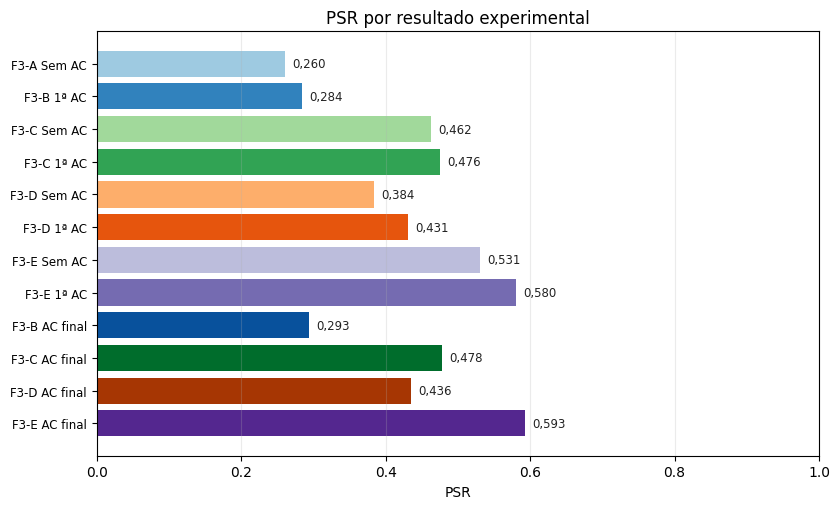

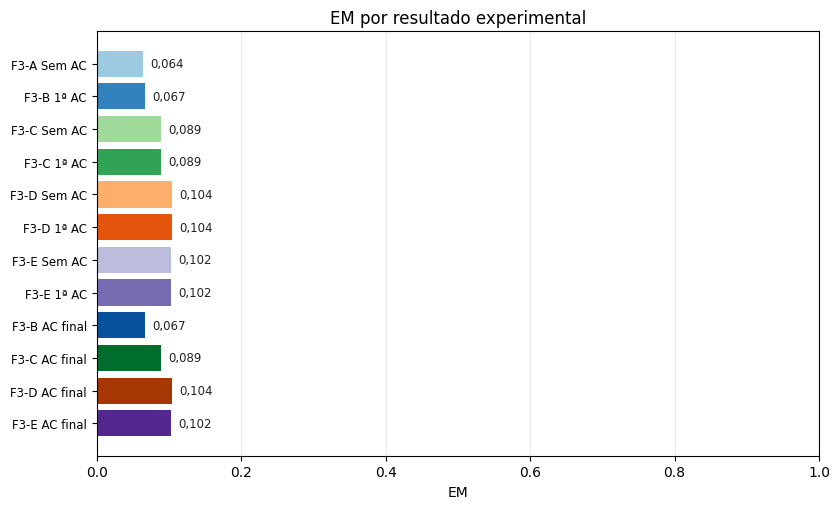

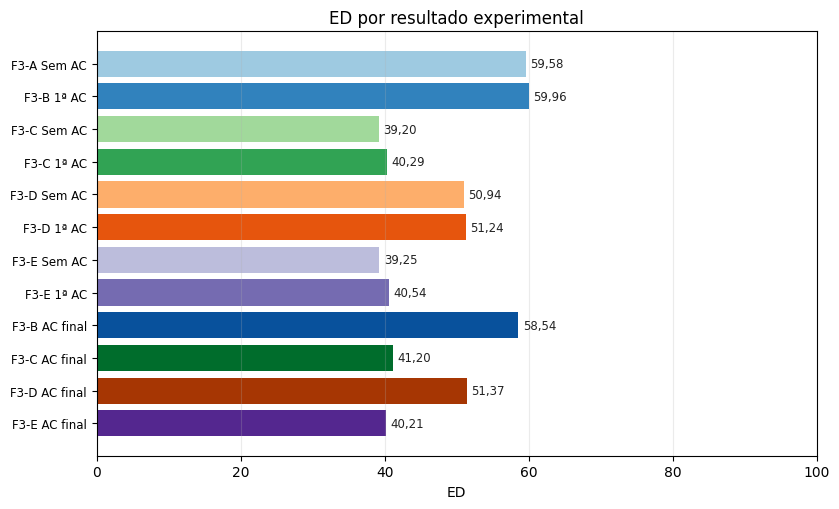

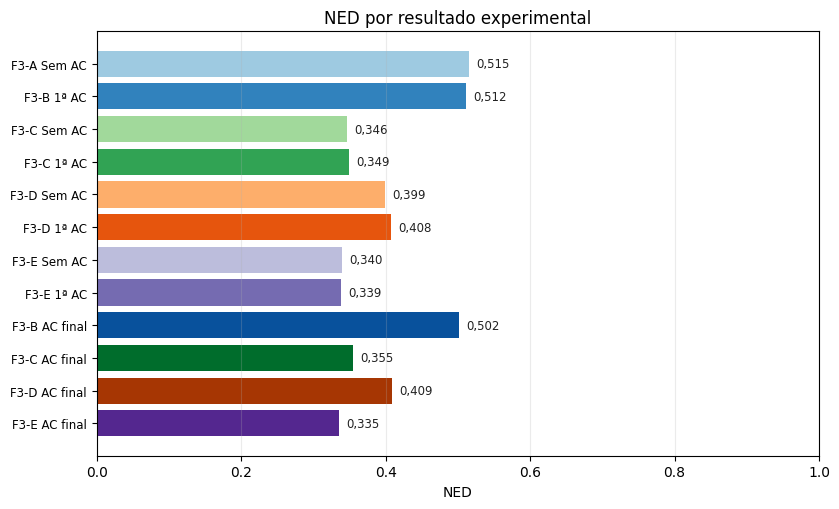

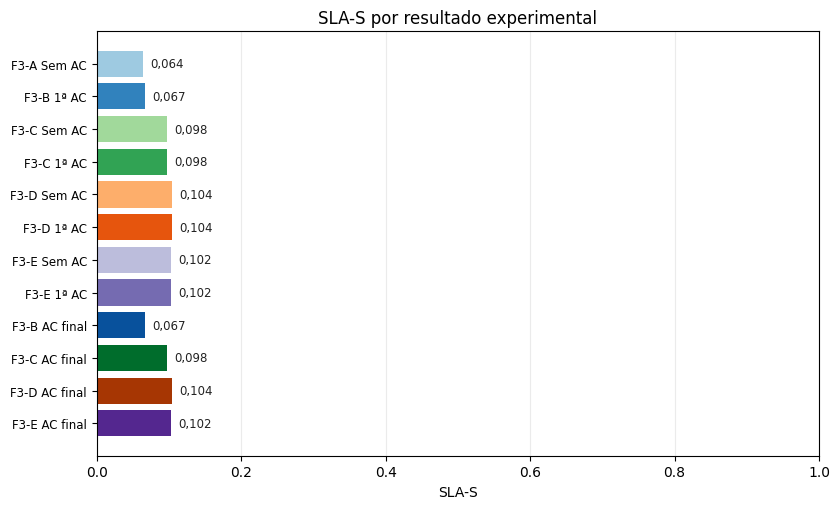

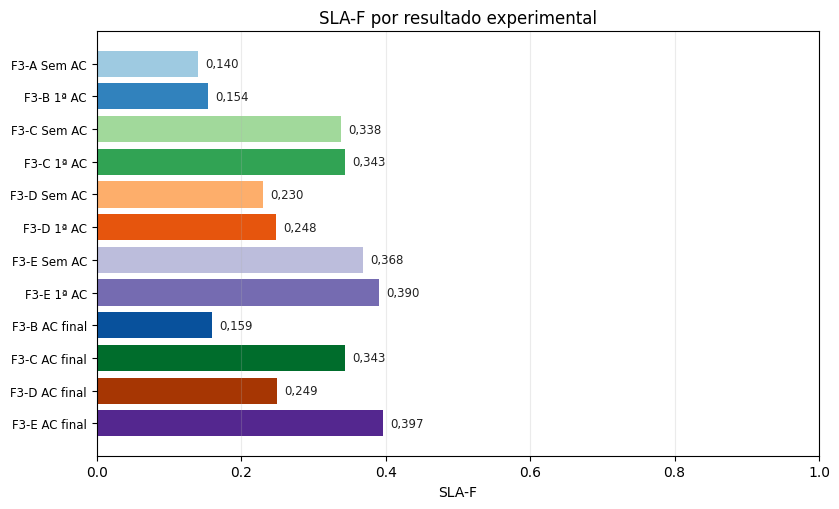

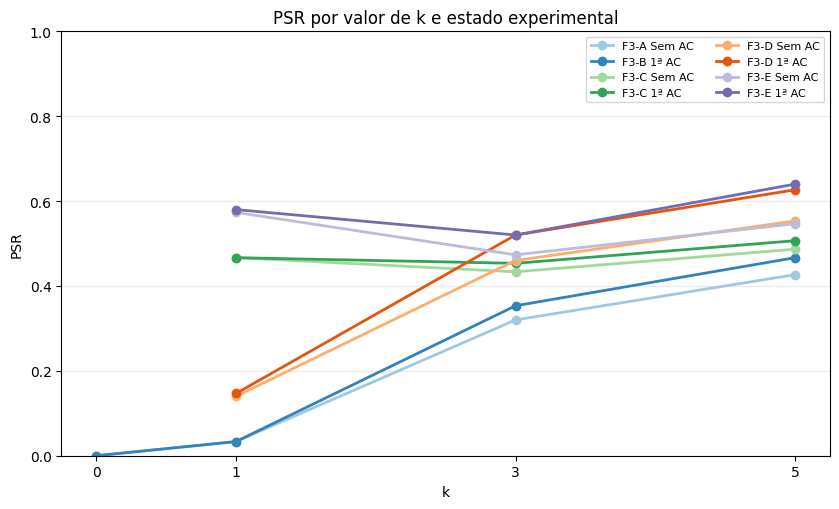

Figura por k: cada linha representa um estado experimental individual.
Média agregada separada: A0, B1, C1, D1 e E1.
k=1: PSR média agregada=0,2520
k=3: PSR média agregada=0,4333
k=5: PSR média agregada=0,5333


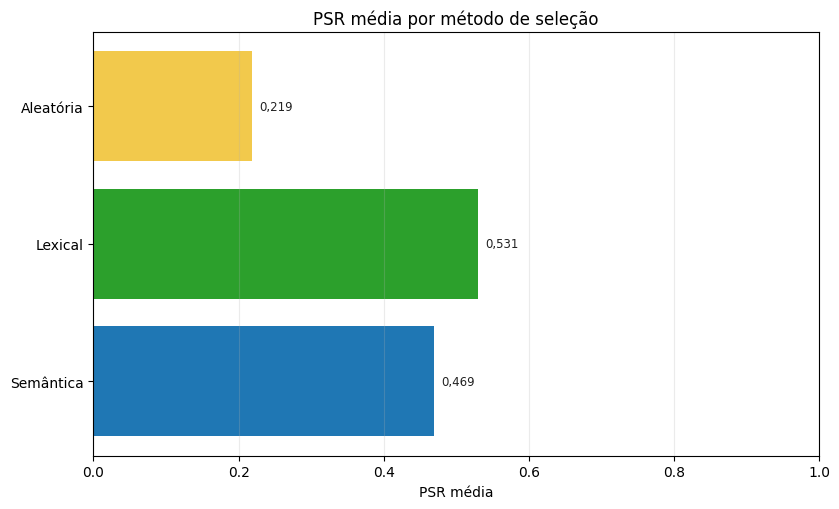

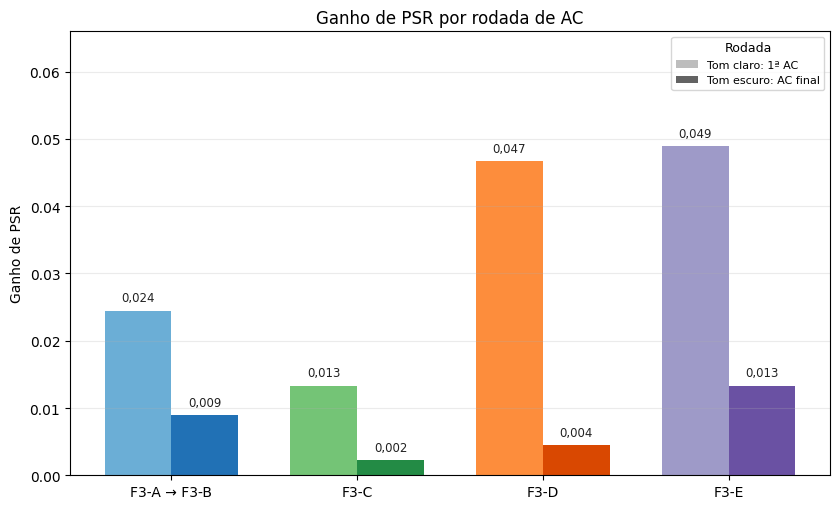

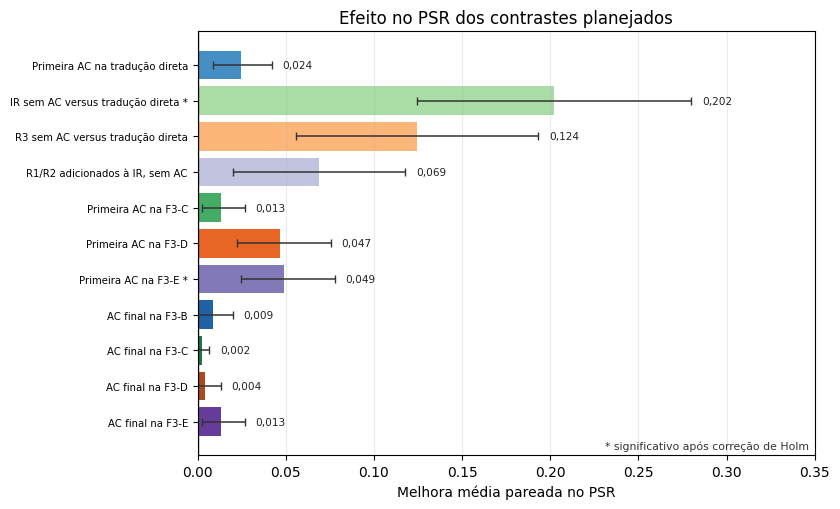

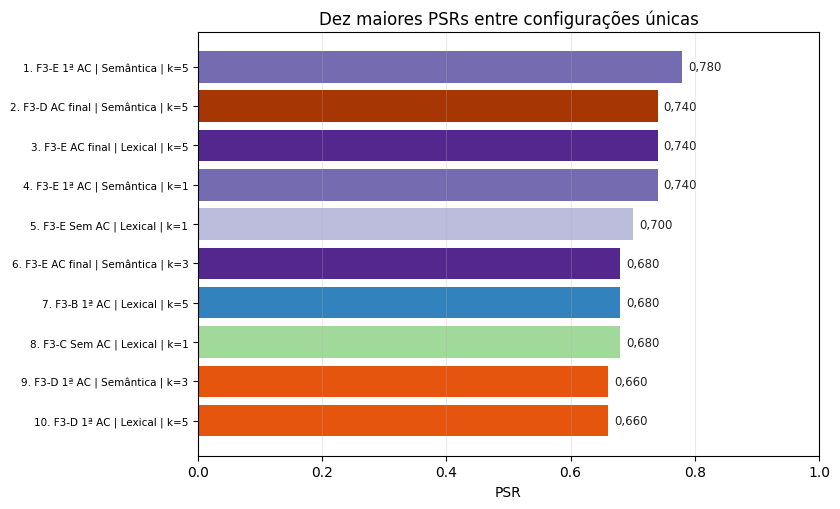

gráfico,largura em pixels,altura em pixels,sha256
f4_grafico_psr_por_resultado.png,1342,809,e15ad209bb16ff3718dfedd389f68734ca838f8db356aefbab997d2a27e3c605
f4_grafico_em_por_resultado.png,1342,809,e1920aeed4db9e323730bbbb6784a96b07170fea79eef289ac8a013b219764c0
f4_grafico_ed_por_resultado.png,1342,809,604c3795eba6c1a3abbc9e2e7e24f662cde25068485c9bd86031ef6b7fe43b3e
f4_grafico_ned_por_resultado.png,1342,809,3ce8aa0ea516c200a687cdb88ee71acbe9efe5377d5d1811745268400c9c994a
f4_grafico_sla_s_por_resultado.png,1342,809,05f2338bb5502412b2a70c504f030d6e48bb6192aa7843f5034e3e0ff1767026
f4_grafico_sla_f_por_resultado.png,1342,809,6062986dea399449a67a0819f227c195a6549374696927c5ed2a2a5655a67803
f4_grafico_psr_por_k_e_resultado.png,1342,809,9d74d83582f08d66fc47a7ad76215ad034e50d0e7295dda3ed72d10edabe8486
f4_grafico_psr_medio_por_metodo.png,1342,809,a16aa8125b9f5e3ea9c8f71743ad99e57d668b2a3bec2e4bf08d55263eb5e3de
f4_grafico_ganho_psr_por_rodada_autocorrecao.png,1342,809,22a45b4a8c6708c4ec9e1f675971355681f8ceb413b530085651ffc5ebafa26f
f4_grafico_efeito_psr_contrastes.png,1342,809,b1ab712d991c24d11c10db754a09716a2d93b2bd0d856d282cb922540d1dd072


Bloco 9 concluído.
Gráficos produzidos: 11
Dimensão padronizada: 1342 × 809 pixels
Estilo visual: padrão da versão anterior da F4
Status: OK


In [9]:
# ----------------------------------------------------------
# 9.1 Configuração gráfica comum
# ----------------------------------------------------------

from matplotlib.patches import Patch
import matplotlib.pyplot as plt

TOTAL_GRAFICOS_ESPERADO = 11

for arquivo_png in GRAFICOS_DIR.glob("*.png"):
    arquivo_png.unlink()

pacote_graficos_dir = PACOTE_DIR / "graficos"
if pacote_graficos_dir.exists():
    shutil.rmtree(pacote_graficos_dir)

LIMITES_GRAFICOS = {
    "psr": (0.0, 1.0),
    "em": (0.0, 1.0),
    "ed": (0.0, 100.0),
    "ned": (0.0, 1.0),
    "sla_s": (0.0, 1.0),
    "sla_f": (0.0, 1.0),
}

ROTULOS_GRAFICOS = {
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}

FIGSIZE_PADRAO = (8.5, 5.2)
DPI_PADRAO = 160


def localizar_primeiro_grafico(root):
    candidatos = sorted(Path(root).rglob("*.png"))
    if not candidatos:
        raise FileNotFoundError(
            "Nenhum gráfico oficial foi localizado na F3-A para referência."
        )
    return candidatos[0]


with Image.open(
    localizar_primeiro_grafico(selected["F3-A"]["root"])
) as imagem_referencia:
    DIMENSAO_REFERENCIA_PX = imagem_referencia.size


def salvar_grafico_padronizado(fig, caminho):
    caminho = Path(caminho)
    caminho.parent.mkdir(parents=True, exist_ok=True)

    fig.tight_layout()
    fig.savefig(
        caminho,
        dpi=DPI_PADRAO,
        bbox_inches="tight",
        facecolor="white",
    )

    with Image.open(caminho) as imagem:
        imagem_rgb = imagem.convert("RGB")
        reamostragem = getattr(
            Image,
            "Resampling",
            Image,
        ).LANCZOS

        imagem_contida = ImageOps.contain(
            imagem_rgb,
            DIMENSAO_REFERENCIA_PX,
            method=reamostragem,
        )

        tela = Image.new(
            "RGB",
            DIMENSAO_REFERENCIA_PX,
            "white",
        )

        deslocamento_x = (
            DIMENSAO_REFERENCIA_PX[0]
            - imagem_contida.width
        ) // 2
        deslocamento_y = (
            DIMENSAO_REFERENCIA_PX[1]
            - imagem_contida.height
        ) // 2

        tela.paste(
            imagem_contida,
            (deslocamento_x, deslocamento_y),
        )
        tela.save(
            caminho,
            format="PNG",
            optimize=True,
        )


def formatar_valor_pt(valor, casas=3):
    return f"{float(valor):.{casas}f}".replace(".", ",")


def rotular_barras_horizontais(
    ax,
    barras,
    casas=3,
    deslocamento=0.01,
):
    for barra in barras:
        largura = float(barra.get_width())
        posicao_y = (
            barra.get_y()
            + barra.get_height() / 2
        )
        ax.text(
            largura + deslocamento,
            posicao_y,
            formatar_valor_pt(
                largura,
                casas=casas,
            ),
            va="center",
            ha="left",
            fontsize=8.5,
            color="#222222",
        )


def rotular_barras_verticais(
    ax,
    barras,
    casas=3,
    deslocamento=0.005,
):
    for barra in barras:
        altura = float(barra.get_height())
        posicao_x = (
            barra.get_x()
            + barra.get_width() / 2
        )
        ax.text(
            posicao_x,
            altura + deslocamento,
            formatar_valor_pt(
                altura,
                casas=casas,
            ),
            va="bottom",
            ha="center",
            fontsize=8.5,
            color="#222222",
        )


ROTULOS_ESTADOS_GRAFICOS = {
    "A0": "F3-A Sem AC",
    "B1": "F3-B 1ª AC",
    "C0": "F3-C Sem AC",
    "C1": "F3-C 1ª AC",
    "D0": "F3-D Sem AC",
    "D1": "F3-D 1ª AC",
    "E0": "F3-E Sem AC",
    "E1": "F3-E 1ª AC",
    "B2": "F3-B AC final",
    "C2": "F3-C AC final",
    "D2": "F3-D AC final",
    "E2": "F3-E AC final",
}

ORDEM_ESTADOS_GRAFICOS = [
    "A0",
    "B1",
    "C0",
    "C1",
    "D0",
    "D1",
    "E0",
    "E1",
    "B2",
    "C2",
    "D2",
    "E2",
]

CORES_ESTADOS_GRAFICOS = {
    "A0": "#9ecae1",
    "B1": "#3182bd",
    "C0": "#a1d99b",
    "C1": "#31a354",
    "D0": "#fdae6b",
    "D1": "#e6550d",
    "E0": "#bcbddc",
    "E1": "#756bb1",
    "B2": "#08519c",
    "C2": "#006d2c",
    "D2": "#a63603",
    "E2": "#54278f",
}

CORES_METODOS_GRAFICOS = {
    "zero_shot": "#d62728",
    "random_seed42": "#f2c94c",
    "lexical_tfidf": "#2ca02c",
    "semantic_embeddings": "#1f77b4",
}

GRAPH_PATHS = []


# ----------------------------------------------------------
# 9.2 Gráficos gerais das seis métricas
# ----------------------------------------------------------

resumo_grafico_df = summary_state_df.copy()
resumo_grafico_df["_ordem"] = (
    resumo_grafico_df["state_code"]
    .map({
        estado: posicao
        for posicao, estado
        in enumerate(ORDEM_ESTADOS_GRAFICOS)
    })
)
resumo_grafico_df = (
    resumo_grafico_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)

for metrica in METRICAS:
    valores = (
        resumo_grafico_df[metrica]
        .astype(float)
        .to_numpy()
    )
    rotulos = [
        ROTULOS_ESTADOS_GRAFICOS[estado]
        for estado
        in resumo_grafico_df["state_code"]
    ]
    cores = [
        CORES_ESTADOS_GRAFICOS[estado]
        for estado
        in resumo_grafico_df["state_code"]
    ]

    fig, ax = plt.subplots(
        figsize=FIGSIZE_PADRAO,
    )
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    barras = ax.barh(
        rotulos,
        valores,
        color=cores,
    )

    ax.set_title(
        f"{ROTULOS_GRAFICOS[metrica]} "
        "por resultado experimental"
    )
    ax.set_xlabel(
        ROTULOS_GRAFICOS[metrica]
    )
    ax.set_xlim(
        *LIMITES_GRAFICOS[metrica]
    )
    ax.grid(
        axis="x",
        alpha=0.25,
    )
    ax.invert_yaxis()
    ax.tick_params(
        axis="y",
        labelsize=8.5,
    )

    deslocamento = (
        0.6
        if metrica == "ed"
        else 0.01
    )
    casas = (
        2
        if metrica == "ed"
        else 3
    )
    rotular_barras_horizontais(
        ax,
        barras,
        casas=casas,
        deslocamento=deslocamento,
    )

    caminho = (
        GRAFICOS_DIR
        / f"f4_grafico_{metrica}_por_resultado.png"
    )
    salvar_grafico_padronizado(
        fig,
        caminho,
    )
    plt.show()
    plt.close(fig)
    GRAPH_PATHS.append(caminho)


# ----------------------------------------------------------
# 9.3 PSR por valor de k e estado experimental
# ----------------------------------------------------------

# Cada linha do gráfico representa um estado experimental.
# A autocorreção final não integra esta figura.
estados_antes_ac_final = [
    "A0",
    "B1",
    "C0",
    "C1",
    "D0",
    "D1",
    "E0",
    "E1",
]

# Em k = 1, 3 e 5, cada ponto corresponde à média da PSR
# dos métodos aleatório, lexical e semântico dentro do
# respectivo estado experimental. Em k = 0, existem apenas
# A0 e B1, pois o zero-shot não possui método de seleção.
psr_k_por_estado_df = (
    summary_method_k_df.loc[
        summary_method_k_df["state_code"].isin(
            estados_antes_ac_final
        )
    ]
    .groupby(
        ["state_code", "k"],
        dropna=False,
    )
    .agg(
        psr=("psr", "mean"),
    )
    .reset_index()
)

# A média agregada citada no texto da dissertação é calculada
# separadamente. Ela reúne somente os cinco estados da
# comparação principal e não é desenhada como uma linha.
psr_k_media_principal_df = (
    main_comparison_df
    .groupby(
        "k",
        dropna=False,
    )
    .agg(
        psr_media_cinco_estados=("psr", "mean"),
        registros=("psr", "size"),
    )
    .reset_index()
    .sort_values("k")
    .reset_index(drop=True)
)

valores_k_esperados = {1, 3, 5}
valores_k_observados = set(
    psr_k_media_principal_df["k"]
    .astype(int)
    .tolist()
)

if valores_k_observados != valores_k_esperados:
    raise ValueError(
        "A média das cinco estratégias principais deve "
        "conter somente k = 1, k = 3 e k = 5. "
        f"Valores observados: {sorted(valores_k_observados)}."
    )

if not (
    psr_k_media_principal_df["registros"]
    .eq(750)
    .all()
):
    raise ValueError(
        "Cada valor de k deve reunir 750 registros: "
        "5 estados × 3 métodos × 50 exemplos."
    )

fig, ax = plt.subplots(
    figsize=FIGSIZE_PADRAO,
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for estado in estados_antes_ac_final:
    parte = (
        psr_k_por_estado_df.loc[
            psr_k_por_estado_df["state_code"] == estado
        ]
        .sort_values("k")
    )

    if parte.empty:
        continue

    ax.plot(
        parte["k"],
        parte["psr"],
        marker="o",
        linewidth=2,
        label=ROTULOS_ESTADOS_GRAFICOS[estado],
        color=CORES_ESTADOS_GRAFICOS[estado],
    )

ax.set_title(
    "PSR por valor de k e estado experimental"
)
ax.set_xlabel("k")
ax.set_ylabel("PSR")
ax.set_xticks([0, 1, 3, 5])
ax.set_ylim(0, 1)
ax.set_yticks(
    np.arange(0.0, 1.01, 0.2)
)
ax.grid(
    axis="y",
    alpha=0.25,
)
ax.legend(
    loc="best",
    fontsize=8,
    ncol=2,
)

caminho = (
    GRAFICOS_DIR
    / "f4_grafico_psr_por_k_e_resultado.png"
)
salvar_grafico_padronizado(
    fig,
    caminho,
)
plt.show()
plt.close(fig)
GRAPH_PATHS.append(caminho)

print(
    "Figura por k: cada linha representa um estado "
    "experimental individual."
)
print(
    "Média agregada separada: A0, B1, C1, D1 e E1."
)
for registro in psr_k_media_principal_df.itertuples(
    index=False
):
    print(
        f"k={int(registro.k)}: "
        f"PSR média agregada="
        f"{formatar_valor_pt(registro.psr_media_cinco_estados, 4)}"
    )


# ----------------------------------------------------------
# 9.4 PSR média por método de seleção
# ----------------------------------------------------------

# O zero-shot é um regime de inferência, não um método de
# seleção. Este gráfico utiliza somente os 2.250 registros
# few-shot da comparação principal.
dados_metodo_fonte = (
    main_comparison_df.loc[
        main_comparison_df["k"].isin([1, 3, 5])
        & main_comparison_df["selection_method"].isin(
            METODOS_FEWSHOT
        )
    ]
    .copy()
)

metodos_esperados = set(METODOS_FEWSHOT)
metodos_observados = set(
    dados_metodo_fonte["selection_method"]
    .dropna()
    .unique()
)

if metodos_observados != metodos_esperados:
    raise ValueError(
        "Os métodos disponíveis não correspondem às "
        "seleções aleatória, lexical e semântica. "
        f"Observados: {sorted(metodos_observados)}."
    )

if (
    dados_metodo_fonte["selection_method"]
    .eq("zero_shot")
    .any()
):
    raise ValueError(
        "O regime zero-shot foi incluído indevidamente no "
        "gráfico por método de seleção."
    )

psr_metodo_df = (
    dados_metodo_fonte
    .groupby(
        "selection_method",
        dropna=False,
    )
    .agg(
        psr=("psr", "mean"),
        registros=("psr", "size"),
    )
    .reset_index()
)

psr_metodo_df["_ordem"] = (
    psr_metodo_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
psr_metodo_df = (
    psr_metodo_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)

if len(psr_metodo_df) != 3:
    raise ValueError(
        "O gráfico por método deve apresentar exatamente "
        "três barras."
    )

fig, ax = plt.subplots(
    figsize=FIGSIZE_PADRAO,
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

barras = ax.barh(
    [
        ROTULOS_METODOS[metodo]
        for metodo
        in psr_metodo_df["selection_method"]
    ],
    psr_metodo_df["psr"],
    color=[
        CORES_METODOS_GRAFICOS[metodo]
        for metodo
        in psr_metodo_df["selection_method"]
    ],
)

ax.set_title(
    "PSR média por método de seleção"
)
ax.set_xlabel("PSR média")
ax.set_xlim(0, 1)
ax.set_xticks(
    np.arange(0.0, 1.01, 0.2)
)
ax.grid(
    axis="x",
    alpha=0.25,
)
ax.invert_yaxis()

rotular_barras_horizontais(
    ax,
    barras,
    casas=3,
    deslocamento=0.01,
)

caminho = (
    GRAFICOS_DIR
    / "f4_grafico_psr_medio_por_metodo.png"
)
salvar_grafico_padronizado(
    fig,
    caminho,
)
plt.show()
plt.close(fig)
GRAPH_PATHS.append(caminho)


# ----------------------------------------------------------
# 9.5 Ganho de PSR por rodada de autocorreção
# ----------------------------------------------------------

psr_por_estado = (
    summary_state_df
    .set_index("state_code")["psr"]
    .astype(float)
    .to_dict()
)

grupos_ac = [
    "F3-A → F3-B",
    "F3-C",
    "F3-D",
    "F3-E",
]

pares_primeira_ac = [
    ("A0", "B1"),
    ("C0", "C1"),
    ("D0", "D1"),
    ("E0", "E1"),
]

pares_ac_final = [
    ("B1", "B2"),
    ("C1", "C2"),
    ("D1", "D2"),
    ("E1", "E2"),
]

ganhos_primeira = np.array([
    psr_por_estado[depois]
    - psr_por_estado[antes]
    for antes, depois
    in pares_primeira_ac
])

ganhos_finais = np.array([
    psr_por_estado[depois]
    - psr_por_estado[antes]
    for antes, depois
    in pares_ac_final
])

cores_primeira = [
    "#6baed6",
    "#74c476",
    "#fd8d3c",
    "#9e9ac8",
]
cores_final = [
    "#2171b5",
    "#238b45",
    "#d94801",
    "#6a51a3",
]

fig, ax = plt.subplots(
    figsize=FIGSIZE_PADRAO,
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

posicoes = np.arange(
    len(grupos_ac)
)
largura = 0.36

barras_primeira = ax.bar(
    posicoes - largura / 2,
    ganhos_primeira,
    width=largura,
    color=cores_primeira,
)

barras_finais = ax.bar(
    posicoes + largura / 2,
    ganhos_finais,
    width=largura,
    color=cores_final,
)

ax.set_title(
    "Ganho de PSR por rodada de AC"
)
ax.set_ylabel("Ganho de PSR")
ax.set_xticks(posicoes)
ax.set_xticklabels(grupos_ac)
ax.grid(
    axis="y",
    alpha=0.25,
)

limite_superior = max(
    float(ganhos_primeira.max()),
    float(ganhos_finais.max()),
    0.01,
) * 1.35
ax.set_ylim(
    0,
    limite_superior,
)

rotular_barras_verticais(
    ax,
    barras_primeira,
    casas=3,
    deslocamento=limite_superior * 0.015,
)
rotular_barras_verticais(
    ax,
    barras_finais,
    casas=3,
    deslocamento=limite_superior * 0.015,
)

ax.legend(
    handles=[
        Patch(
            facecolor="#bdbdbd",
            edgecolor="none",
            label="Tom claro: 1ª AC",
        ),
        Patch(
            facecolor="#636363",
            edgecolor="none",
            label="Tom escuro: AC final",
        ),
    ],
    loc="upper right",
    frameon=True,
    title="Rodada",
    fontsize=8,
    title_fontsize=9,
)

caminho = (
    GRAFICOS_DIR
    / "f4_grafico_ganho_psr_por_rodada_autocorrecao.png"
)
salvar_grafico_padronizado(
    fig,
    caminho,
)
plt.show()
plt.close(fig)
GRAPH_PATHS.append(caminho)


# ----------------------------------------------------------
# 9.6 Efeito no PSR dos contrastes planejados
# ----------------------------------------------------------

efeitos_psr_df = planned_contrasts_df.loc[
    planned_contrasts_df["metric"] == "psr"
].copy()

efeitos_psr_df["_ordem"] = (
    efeitos_psr_df["contrast"]
    .map({
        item["contrast"]: posicao
        for posicao, item
        in enumerate(PLANNED_CONTRASTS)
    })
)
efeitos_psr_df = (
    efeitos_psr_df
    .sort_values("_ordem")
    .drop(columns="_ordem")
    .reset_index(drop=True)
)

valores_efeito = (
    efeitos_psr_df["example_mean_improvement"]
    .astype(float)
    .to_numpy()
)
limites_inferiores = (
    efeitos_psr_df["ci_low"]
    .astype(float)
    .to_numpy()
)
limites_superiores = (
    efeitos_psr_df["ci_high"]
    .astype(float)
    .to_numpy()
)

erros_assimetricos = np.vstack([
    valores_efeito - limites_inferiores,
    limites_superiores - valores_efeito,
])

rotulos_efeitos = [
    (
        f"{rotulo} *"
        if significativo
        else rotulo
    )
    for rotulo, significativo
    in zip(
        efeitos_psr_df["contrast_label"],
        efeitos_psr_df["significant_holm"],
    )
]

cores_efeitos = [
    CORES_ESTADOS_GRAFICOS.get(
        estado,
        "#7f7f7f",
    )
    for estado
    in efeitos_psr_df["right_state"]
]

fig, ax = plt.subplots(
    figsize=FIGSIZE_PADRAO,
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

posicoes_efeitos = np.arange(
    len(efeitos_psr_df)
)

barras = ax.barh(
    posicoes_efeitos,
    valores_efeito,
    color=cores_efeitos,
    alpha=0.90,
)

ax.errorbar(
    valores_efeito,
    posicoes_efeitos,
    xerr=erros_assimetricos,
    fmt="none",
    ecolor="#333333",
    elinewidth=1.1,
    capsize=3,
)

ax.axvline(
    0.0,
    color="#444444",
    linewidth=1.0,
)

ax.set_title(
    "Efeito no PSR dos contrastes planejados"
)
ax.set_xlabel(
    "Melhora média pareada no PSR"
)
ax.set_yticks(posicoes_efeitos)
ax.set_yticklabels(
    rotulos_efeitos,
    fontsize=7.3,
)
# O eixo começa em zero quando todos os intervalos de confiança
# são não negativos. Um intervalo negativo só é aberto quando os
# próprios resultados exigirem essa área.
menor_limite_observado = float(
    limites_inferiores.min()
)
maior_limite_observado = float(
    limites_superiores.max()
)

if menor_limite_observado < 0:
    limite_x_inferior = (
        math.floor(
            (menor_limite_observado - 0.01) / 0.05
        )
        * 0.05
    )
else:
    limite_x_inferior = 0.0

limite_x_superior = max(
    0.35,
    math.ceil(
        (maior_limite_observado + 0.03) / 0.05
    )
    * 0.05,
)

ax.set_xlim(
    limite_x_inferior,
    limite_x_superior,
)
ax.set_xticks(
    np.arange(
        limite_x_inferior,
        limite_x_superior + 0.001,
        0.05,
    )
)
ax.grid(
    axis="x",
    alpha=0.25,
)
ax.invert_yaxis()

for (
    barra,
    valor,
    limite_inferior,
    limite_superior,
) in zip(
    barras,
    valores_efeito,
    limites_inferiores,
    limites_superiores,
):
    posicao_y = (
        barra.get_y()
        + barra.get_height() / 2
    )

    # O valor é apresentado depois da extremidade do intervalo
    # de confiança. Assim, todos os números ficam alinhados ao
    # final das linhas, sem sobreposição com as barras ou whiskers.
    if limite_superior >= 0:
        posicao_x = (
            float(limite_superior)
            + 0.006
        )
        alinhamento = "left"
    else:
        posicao_x = (
            float(limite_inferior)
            - 0.006
        )
        alinhamento = "right"

    ax.text(
        posicao_x,
        posicao_y,
        formatar_valor_pt(
            valor,
            casas=3,
        ),
        va="center",
        ha=alinhamento,
        fontsize=7.6,
        color="#222222",
        clip_on=False,
    )

ax.text(
    0.99,
    0.01,
    "* significativo após correção de Holm",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=7.8,
    color="#333333",
)

caminho = (
    GRAFICOS_DIR
    / "f4_grafico_efeito_psr_contrastes.png"
)
salvar_grafico_padronizado(
    fig,
    caminho,
)
plt.show()
plt.close(fig)
GRAPH_PATHS.append(caminho)


# ----------------------------------------------------------
# 9.7 Dez maiores PSRs entre configurações únicas
# ----------------------------------------------------------

# Cada combinação de estratégia, método e k pode aparecer em
# diferentes estados de autocorreção. Mantém-se o estado com
# maior PSR. Em caso de empate, preserva-se o estado anterior,
# pois a etapa posterior não acrescentou ganho de PSR.
ordem_etapas_ranking = {
    "sem_ac": 0,
    "primeira_ac": 1,
    "autocorrecao_final": 2,
}

ranking_df = (
    summary_method_k_df.loc[
        summary_method_k_df["k"].isin([1, 3, 5])
        & summary_method_k_df["selection_method"].isin(
            METODOS_FEWSHOT
        )
    ]
    .copy()
)

ranking_df["_ordem_etapa"] = (
    ranking_df["analysis_stage"]
    .map(ordem_etapas_ranking)
)

if ranking_df["_ordem_etapa"].isna().any():
    etapas_invalidas = sorted(
        ranking_df.loc[
            ranking_df["_ordem_etapa"].isna(),
            "analysis_stage",
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
    raise ValueError(
        "Há etapas sem prioridade definida no ranking: "
        f"{etapas_invalidas}."
    )

ranking_df = (
    ranking_df
    .sort_values(
        [
            "strategy",
            "selection_method",
            "k",
            "psr",
            "_ordem_etapa",
        ],
        ascending=[
            True,
            True,
            True,
            False,
            True,
        ],
    )
    .drop_duplicates(
        subset=[
            "strategy",
            "selection_method",
            "k",
        ],
        keep="first",
    )
    .reset_index(drop=True)
)

if ranking_df.duplicated(
    subset=[
        "strategy",
        "selection_method",
        "k",
    ]
).any():
    raise ValueError(
        "O ranking ainda contém combinações duplicadas."
    )

ranking_df["_ordem_estado"] = (
    ranking_df["state_code"]
    .map({
        estado: posicao
        for posicao, estado
        in enumerate(ORDEM_ESTADOS_GRAFICOS)
    })
)
ranking_df["_ordem_metodo"] = (
    ranking_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)

ranking_df = (
    ranking_df
    .sort_values(
        [
            "psr",
            "em",
            "sla_s",
            "sla_f",
            "ned",
            "_ordem_estado",
            "_ordem_metodo",
            "k",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            True,
            True,
            True,
            False,
        ],
    )
    .head(10)
    .reset_index(drop=True)
)

ranking_df["posição"] = (
    np.arange(
        1,
        len(ranking_df) + 1,
    )
)

ranking_df["rótulo"] = ranking_df.apply(
    lambda linha: (
        f"{int(linha['posição'])}. "
        f"{ROTULOS_ESTADOS_GRAFICOS[linha['state_code']]} "
        f"| {ROTULOS_METODOS[linha['selection_method']]} "
        f"| k={int(linha['k'])}"
    ),
    axis=1,
)

fig, ax = plt.subplots(
    figsize=FIGSIZE_PADRAO,
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

barras = ax.barh(
    ranking_df["rótulo"],
    ranking_df["psr"],
    color=[
        CORES_ESTADOS_GRAFICOS[estado]
        for estado
        in ranking_df["state_code"]
    ],
)

ax.set_title(
    "Dez maiores PSRs entre configurações únicas"
)
ax.set_xlabel("PSR")
ax.set_xlim(0, 1)
ax.set_xticks(
    np.arange(0.0, 1.01, 0.2)
)
ax.grid(
    axis="x",
    alpha=0.25,
)
ax.invert_yaxis()
ax.tick_params(
    axis="y",
    labelsize=7.5,
)

rotular_barras_horizontais(
    ax,
    barras,
    casas=3,
    deslocamento=0.01,
)

caminho = (
    GRAFICOS_DIR
    / "f4_grafico_top10_configuracoes_psr.png"
)
salvar_grafico_padronizado(
    fig,
    caminho,
)
plt.show()
plt.close(fig)
GRAPH_PATHS.append(caminho)


# ----------------------------------------------------------
# 9.8 Auditoria dos gráficos
# ----------------------------------------------------------

if len(GRAPH_PATHS) != TOTAL_GRAFICOS_ESPERADO:
    raise ValueError(
        f"Foram produzidos {len(GRAPH_PATHS)} gráficos; "
        f"eram esperados {TOTAL_GRAFICOS_ESPERADO}."
    )

graph_inventory_rows = []

for caminho in GRAPH_PATHS:
    if not caminho.is_file():
        raise FileNotFoundError(
            caminho
        )

    with Image.open(caminho) as imagem:
        largura_px, altura_px = imagem.size

    graph_inventory_rows.append({
        "graph": caminho.name,
        "width_px": largura_px,
        "height_px": altura_px,
        "sha256": sha256_file(caminho),
    })

graph_inventory_df = pd.DataFrame(
    graph_inventory_rows
)

if not (
    graph_inventory_df["width_px"]
    .eq(DIMENSAO_REFERENCIA_PX[0])
    .all()
    and graph_inventory_df["height_px"]
    .eq(DIMENSAO_REFERENCIA_PX[1])
    .all()
):
    raise ValueError(
        "Há gráficos da F4 com dimensão diferente "
        "da referência utilizada nos notebooks novos da F3."
    )

graph_inventory_df.to_csv(
    ARQUIVOS_SAIDA["graph_inventory"],
    index=False,
    encoding="utf-8",
)

exibir_tabela(
    graph_inventory_df,
    "Inventário dos gráficos finais",
    altura_px=470,
)

print("Bloco 9 concluído.")
print(
    f"Gráficos produzidos: "
    f"{len(GRAPH_PATHS)}"
)
print(
    "Dimensão padronizada: "
    f"{DIMENSAO_REFERENCIA_PX[0]} × "
    f"{DIMENSAO_REFERENCIA_PX[1]} pixels"
)
print(
    "Estilo visual: padrão da versão anterior da F4"
)
print("Status: OK")

## Bloco 10 - Barreiras finais, manifestos e empacotamento

### Objetivo

Este bloco confirma a integridade da F4, cria o manifesto interno do pacote, gera o manifesto mestre da entrega e fecha o pacote final de consolidação com base exclusivamente nas seis métricas oficiais.

### Barreiras finais

O empacotamento exige:

- seis fontes auditadas;
- doze estados e 5.550 registros consolidados;
- 2.250 registros na comparação principal;
- 1.800 registros na comparação sem AC;
- 2.250 registros na comparação após AC final;
- onze contrastes planejados;
- 66 testes pareados de Wilcoxon;
- 33 resumos descritivos de transições binárias;
- 11 gráficos com dimensão padronizada;
- ausência de registros duplicados ou não concluídos;
- todos os arquivos tabulares e computacionais presentes;
- dez datasets operacionais anteriores disponíveis nos dados de entrada do Kaggle.

### Manifesto interno da F4

O arquivo `manifest.json` registra os arquivos internos do pacote da F4, seus tamanhos e seus identificadores de integridade. Também documenta as métricas, os estados, as visões analíticas, os parâmetros estatísticos e o ambiente computacional.

### Manifesto mestre da entrega

Os arquivos `manifesto_mestre_entrega.json` e `manifesto_mestre_entrega.csv` registram os onze notebooks e os onze pacotes operacionais do trabalho. Como o Kaggle não monta automaticamente os notebooks das fases como arquivos `.ipynb`, os notebooks são registrados como referências do repositório público. Os dez pacotes anteriores são verificados diretamente a partir dos diretórios dos datasets montados em `/kaggle/input`. Para cada diretório, o notebook calcula a quantidade de arquivos, o tamanho total e um identificador determinístico do conteúdo. O pacote da F4 é registrado como o contêiner atual, cujo identificador definitivo é gravado externamente após o fechamento do ZIP.

### Resultado esperado

O arquivo `f4_consolidacao_resultados.zip` contém os dados consolidados, as tabelas, os testes de Wilcoxon, os intervalos de confiança, os resumos descritivos das transições binárias, os onze gráficos, o manifesto interno e as versões JSON e CSV do manifesto mestre. O arquivo `f4_consolidacao_resultados.zip.sha256` é gerado fora do ZIP e permite verificar o pacote final já fechado.

In [10]:
# ----------------------------------------------------------
# 10.0 Compatibilidade com a versão analítica final
# ----------------------------------------------------------

TOTAL_GRAFICOS_ESPERADO = 11


# ----------------------------------------------------------
# 10.1 Barreiras finais
# ----------------------------------------------------------

required_paths = [
    path
    for key, path in ARQUIVOS_SAIDA.items()
    if key != "config"
]

for path in required_paths:
    if not Path(path).is_file():
        raise FileNotFoundError(path)

if len(input_audit_df) != 6:
    raise ValueError("A F4 exige seis fontes auditadas.")
if len(state_inventory_df) != TOTAL_ESTADOS_ESPERADO:
    raise ValueError("O inventário não possui doze estados.")
if len(all_states_df) != TOTAL_REGISTROS_ESTADOS_ESPERADO:
    raise ValueError("A consolidação não possui 5.550 registros.")
if len(main_comparison_df) != TOTAL_REGISTROS_MAIN_ESPERADO:
    raise ValueError("A comparação principal não possui 2.250 registros.")
if len(sem_ac_comparison_df) != TOTAL_REGISTROS_SEM_AC_ESPERADO:
    raise ValueError("A comparação sem AC não possui 1.800 registros.")
if len(final_comparison_df) != TOTAL_REGISTROS_FINAL_ESPERADO:
    raise ValueError("A comparação final não possui 2.250 registros.")
if len(planned_contrasts_df) != len(PLANNED_CONTRASTS) * len(METRICAS):
    raise ValueError("A quantidade de testes pareados está incorreta.")
if len(binary_transitions_df) != len(PLANNED_CONTRASTS) * len(METRICAS_BINARIAS):
    raise ValueError(
        "A quantidade de resumos descritivos de transições binárias "
        "está incorreta."
    )
if {
    "p_value",
    "p_holm",
    "significant_holm",
} & set(binary_transitions_df.columns):
    raise ValueError(
        "As transições binárias não podem conter resultados inferenciais."
    )
if len(graph_inventory_df) != TOTAL_GRAFICOS_ESPERADO:
    raise ValueError(
        f"O inventário não possui "
        f"{TOTAL_GRAFICOS_ESPERADO} gráficos."
    )
if not all_states_df["status"].eq("completed").all():
    raise ValueError("Há estados com status diferente de completed.")
if WILCOXON_ALTERNATIVE != "two-sided":
    raise ValueError("O Wilcoxon deve permanecer bicaudal.")
if WILCOXON_ZERO_METHOD != "wilcox":
    raise ValueError(
        "O tratamento de zeros deve permanecer como wilcox."
    )
if BOOTSTRAP_CI_METHOD != "percentile":
    raise ValueError(
        "O intervalo bootstrap deve permanecer percentil."
    )
if tuple(BOOTSTRAP_CI_QUANTILES) != (
    ALPHA / 2,
    1 - ALPHA / 2,
):
    raise ValueError("Os quantis bootstrap estão incorretos.")


# ----------------------------------------------------------
# 10.2 Configuração final e inventário
# ----------------------------------------------------------

config_final = {
    "phase": FASE,
    "name": NOME_ETAPA,
    "dataset": DATASET,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "inference_calls": 0,
    "expected": {
        "sources": 6,
        "states": TOTAL_ESTADOS_ESPERADO,
        "all_state_records": TOTAL_REGISTROS_ESTADOS_ESPERADO,
        "main_records": TOTAL_REGISTROS_MAIN_ESPERADO,
        "sem_ac_records": TOTAL_REGISTROS_SEM_AC_ESPERADO,
        "final_records": TOTAL_REGISTROS_FINAL_ESPERADO,
        "graphs": TOTAL_GRAFICOS_ESPERADO,
    },
    "observed": {
        "sources": len(input_audit_df),
        "states": len(state_inventory_df),
        "all_state_records": len(all_states_df),
        "main_records": len(main_comparison_df),
        "sem_ac_records": len(sem_ac_comparison_df),
        "final_records": len(final_comparison_df),
        "planned_contrast_tests": len(planned_contrasts_df),
        "binary_transition_summaries": len(binary_transitions_df),
        "graphs": len(graph_inventory_df),
    },
    "metrics": METRICAS,
    "statistics": {
        "inferential_unit": "CAMPI example",
        "examples": TOTAL_EXEMPLOS_ESPERADO,
        "conditions_per_example": 9,
        "aggregation": "mean paired difference across method and k per example",
        "test": "Wilcoxon signed-rank",
        "wilcoxon_alternative": WILCOXON_ALTERNATIVE,
        "wilcoxon_zero_method": WILCOXON_ZERO_METHOD,
        "wilcoxon_numeric_method": WILCOXON_METHOD,
        "wilcoxon_zero_difference_handling": (
            "zero differences removed before ranking"
        ),
        "wilcoxon_symmetry_assumption": (
            "paired-difference distribution approximately symmetric "
            "for location interpretation"
        ),
        "wilcoxon_metrics": METRICAS,
        "wilcoxon_tests": len(planned_contrasts_df),
        "bootstrap_unit": "CAMPI example",
        "bootstrap_pairing": (
            "paired conditions preserved within each resampled example"
        ),
        "bootstrap_repetitions": BOOTSTRAP_REPETICOES,
        "bootstrap_ci_method": BOOTSTRAP_CI_METHOD,
        "bootstrap_ci_quantiles": list(BOOTSTRAP_CI_QUANTILES),
        "bootstrap_target": "mean paired difference",
        "confidence_level": 1 - ALPHA,
        "multiple_testing": "Holm across all Wilcoxon tests",
        "multiple_testing_family_size": len(planned_contrasts_df),
        "binary_transition_metrics": METRICAS_BINARIAS,
        "binary_transition_role": "descriptive only",
        "mcnemar_applied": False,
    },
    "views": {
        "main": MAIN_STATE_CODES,
        "without_autocorrection": SEM_AC_STATE_CODES,
        "after_final_autocorrection": FINAL_STATE_CODES,
        "zero_shot": ["A0", "B1", "B2"],
    },
    "planned_contrasts": PLANNED_CONTRASTS,
    "graph_dimension_px": list(DIMENSAO_REFERENCIA_PX),
}
write_json(config_final, ARQUIVOS_SAIDA["config"])
if not ARQUIVOS_SAIDA["config"].is_file():
    raise FileNotFoundError(ARQUIVOS_SAIDA["config"])

package_files = [
    path
    for path in PACOTE_DIR.rglob("*")
    if path.is_file() and path.name != "manifest.json"
]

pacote_graficos_dir = PACOTE_DIR / "graficos"
if pacote_graficos_dir.exists():
    shutil.rmtree(pacote_graficos_dir)
pacote_graficos_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for graph_path in GRAPH_PATHS:
    destination = PACOTE_DIR / "graficos" / graph_path.name
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(graph_path, destination)


# ----------------------------------------------------------
# 10.2.1 Criação do manifesto mestre da entrega
# ----------------------------------------------------------

entradas_manifesto_mestre = []

# Os notebooks são referenciados pelo nome e pelo repositório.
# A execução do Kaggle não disponibiliza os arquivos .ipynb
# das fases anteriores para leitura direta.
for especificacao in NOTEBOOKS_MESTRE:
    entradas_manifesto_mestre.append({
        "ordem": int(
            especificacao["ordem"]
        ),
        "tipo": "notebook",
        "fase": especificacao["fase"],
        "nome": especificacao["nome"],
        "source_type": (
            "repository_reference"
        ),
        "source": REPOSITORIO_TRABALHO,
        "runtime_available": False,
        "size_bytes": None,
        "sha256": None,
        "status": (
            "referenciado_no_repositorio"
        ),
    })

# Os dez pacotes anteriores são datasets montados como
# diretórios em /kaggle/input. O identificador calculado
# representa deterministicamente a árvore de arquivos.
for especificacao in PACOTES_MESTRE_ANTERIORES:
    resumo = localizar_dataset_entrega(
        especificacao
    )
    caminho = resumo["path"]

    entradas_manifesto_mestre.append({
        "ordem": int(
            especificacao["ordem"]
        ),
        "tipo": "pacote",
        "fase": especificacao["fase"],
        "nome": especificacao["nome"],
        "source_type": (
            "kaggle_dataset_directory"
        ),
        "source_path": (
            caminho_relativo_a_raiz(
                caminho
            )
        ),
        "runtime_available": True,
        "files": int(
            resumo["files"]
        ),
        "size_bytes": int(
            resumo["size_bytes"]
        ),
        "sha256": (
            resumo["sha256_tree"]
        ),
        "hash_scope": (
            "relative paths, file sizes "
            "and file contents"
        ),
        "status": "verificado",
        "copies_with_identical_hash": int(
            resumo[
                "copies_with_identical_hash"
            ]
        ),
    })

# O pacote F4 contém o próprio manifesto mestre. Seu hash
# definitivo não pode ser escrito dentro do mesmo ZIP sem
# produzir uma referência circular.
entradas_manifesto_mestre.append({
    "ordem": 11,
    "tipo": "pacote",
    "fase": "F4",
    "nome": ZIP_FINAL_PATH.name,
    "source_type": "current_container",
    "source_path": None,
    "runtime_available": True,
    "files": None,
    "size_bytes": None,
    "sha256": None,
    "status": "contêiner_atual",
    "verification_file": (
        ZIP_SHA256_PATH.name
    ),
    "verification_note": (
        "O identificador definitivo do pacote "
        "é registrado externamente depois do "
        "fechamento do ZIP."
    ),
})

quantidade_notebooks = sum(
    entrada["tipo"] == "notebook"
    for entrada in entradas_manifesto_mestre
)
quantidade_pacotes = sum(
    entrada["tipo"] == "pacote"
    for entrada in entradas_manifesto_mestre
)
pacotes_verificados = sum(
    entrada["tipo"] == "pacote"
    and entrada["status"] == "verificado"
    for entrada in entradas_manifesto_mestre
)
notebooks_referenciados = sum(
    entrada["tipo"] == "notebook"
    and entrada["status"]
    == "referenciado_no_repositorio"
    for entrada in entradas_manifesto_mestre
)

if quantidade_notebooks != 11:
    raise ValueError(
        "O manifesto mestre deve registrar "
        "onze notebooks."
    )
if quantidade_pacotes != 11:
    raise ValueError(
        "O manifesto mestre deve registrar "
        "onze pacotes."
    )
if pacotes_verificados != 10:
    raise ValueError(
        "Os dez pacotes anteriores devem ser "
        "verificados nos datasets do Kaggle."
    )
if notebooks_referenciados != 11:
    raise ValueError(
        "Os onze notebooks devem ser "
        "referenciados no repositório."
    )
if len(entradas_manifesto_mestre) != 22:
    raise ValueError(
        "O manifesto mestre deve possuir "
        "22 entradas."
    )

manifesto_mestre = {
    "title": "Manifesto mestre de entrega",
    "generated_at_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "scope": (
        "11 notebooks e 11 pacotes operacionais"
    ),
    "repository": REPOSITORIO_TRABALHO,
    "generation_phase": FASE,
    "container": ZIP_FINAL_PATH.name,
    "container_verification_file": (
        ZIP_SHA256_PATH.name
    ),
    "verification_model": {
        "notebooks": (
            "referências do repositório; "
            "arquivos não montados no runtime"
        ),
        "previous_packages": (
            "conteúdo dos dez diretórios de "
            "datasets montados no Kaggle"
        ),
        "current_package": (
            "hash externo após fechamento do ZIP"
        ),
    },
    "note": (
        "O pacote F4 é o contêiner deste "
        "manifesto. Seu identificador "
        "definitivo é registrado externamente "
        "após o fechamento do ZIP."
    ),
    "entries": entradas_manifesto_mestre,
}

write_json(
    manifesto_mestre,
    MANIFESTO_MESTRE_JSON_PATH,
)

pd.DataFrame(
    entradas_manifesto_mestre
).to_csv(
    MANIFESTO_MESTRE_CSV_PATH,
    index=False,
    encoding="utf-8",
)

for caminho in [
    MANIFESTO_MESTRE_JSON_PATH,
    MANIFESTO_MESTRE_CSV_PATH,
]:
    if not caminho.is_file():
        raise FileNotFoundError(caminho)

print(
    "Manifesto mestre criado com "
    f"{quantidade_notebooks} notebooks "
    "referenciados e "
    f"{pacotes_verificados} pacotes "
    "anteriores verificados."
)


package_files = [
    path
    for path in PACOTE_DIR.rglob("*")
    if path.is_file() and path.name != "manifest.json"
]

file_inventory = []
for path in sorted(
    package_files,
    key=lambda item: str(item.relative_to(PACOTE_DIR)),
):
    file_inventory.append({
        "file": str(path.relative_to(PACOTE_DIR)).replace(os.sep, "/"),
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    })

manifest = {
    "phase": FASE,
    "description": NOME_ETAPA,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": DATASET,
    "inputs": {
        row["source"]: {
            "source_type": row["source_type"],
            "path": row["path"],
            "manifest_sha256": row["manifest_sha256"],
            "expected_manifest_sha256": row["expected_manifest_sha256"],
            "manifest_status": row["manifest_status"],
            "result_file": row["result_file"],
            "records": int(row["records"]),
        }
        for row in input_audit_df.to_dict("records")
    },
    "method": {
        "inference_calls": 0,
        "states": ESTADOS,
        "views": config_final["views"],
        "planned_contrasts": PLANNED_CONTRASTS,
        "statistics": config_final["statistics"],
        "final_autocorrection_is_new_strategy": False,
    },
    "metrics": {
        "official": METRICAS,
        "higher_is_better": ["psr", "em", "sla_s", "sla_f"],
        "lower_is_better": ["ed", "ned"],
    },
    "results": config_final["observed"],
    "visual_analysis": {
        "graphs": TOTAL_GRAFICOS_ESPERADO,
        "dimension_px": list(DIMENSAO_REFERENCIA_PX),
        "fixed_scales": {
            "psr": [0, 1],
            "em": [0, 1],
            "ed": [0, 100],
            "ned": [0, 1],
            "sla_s": [0, 1],
            "sla_f": [0, 1],
        },
    },
    "master_delivery_manifest": {
        "json": str(
            MANIFESTO_MESTRE_JSON_PATH
            .relative_to(PACOTE_DIR)
        ).replace(os.sep, "/"),
        "csv": str(
            MANIFESTO_MESTRE_CSV_PATH
            .relative_to(PACOTE_DIR)
        ).replace(os.sep, "/"),
        "entries": len(
            entradas_manifesto_mestre
        ),
        "notebooks": quantidade_notebooks,
        "notebooks_repository_references": (
            notebooks_referenciados
        ),
        "packages": quantidade_pacotes,
        "previous_packages_verified": (
            pacotes_verificados
        ),
        "container_hash_file": (
            ZIP_SHA256_PATH.name
        ),
    },
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scipy": importlib.metadata.version("scipy"),
        "matplotlib": importlib.metadata.version("matplotlib"),
        "pillow": importlib.metadata.version("pillow"),
    },
    "files": file_inventory,
}
write_json(manifest, MANIFEST_PATH)


# ----------------------------------------------------------
# 10.3 Criação e conferência do ZIP
# ----------------------------------------------------------

if ZIP_FINAL_PATH.exists():
    ZIP_FINAL_PATH.unlink()

with zipfile.ZipFile(
    ZIP_FINAL_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as package:
    for path in sorted(
        PACOTE_DIR.rglob("*"),
        key=lambda item: str(item.relative_to(PACOTE_DIR)),
    ):
        if path.is_file():
            package.write(
                path,
                arcname=str(path.relative_to(PACOTE_DIR)).replace(os.sep, "/"),
            )

with zipfile.ZipFile(ZIP_FINAL_PATH, "r") as package:
    zip_names = set(package.namelist())
    expected_names = {
        item["file"]
        for item in manifest["files"]
    } | {"manifest.json"}
    if zip_names != expected_names:
        missing = sorted(expected_names - zip_names)
        extra = sorted(zip_names - expected_names)
        raise ValueError(
            f"Divergência no ZIP. Ausentes={missing}; extras={extra}"
        )

    manifest_zip = json.loads(package.read("manifest.json"))
    for item in manifest_zip["files"]:
        data = package.read(item["file"])
        if len(data) != int(item["size_bytes"]):
            raise ValueError(
                f"Tamanho divergente no ZIP: {item['file']}"
            )
        if sha256_bytes(data) != item["sha256"]:
            raise ValueError(
                f"SHA-256 divergente no ZIP: {item['file']}"
            )

    for nome_manifesto in [
        "manifesto_mestre_entrega.json",
        "manifesto_mestre_entrega.csv",
    ]:
        if nome_manifesto not in zip_names:
            raise FileNotFoundError(
                f"Manifesto mestre ausente do ZIP: "
                f"{nome_manifesto}"
            )


# ----------------------------------------------------------
# 10.3.1 Verificação externa do pacote final
# ----------------------------------------------------------

zip_sha256 = sha256_file(
    ZIP_FINAL_PATH
)

ZIP_SHA256_PATH.write_text(
    (
        f"{zip_sha256}  "
        f"{ZIP_FINAL_PATH.name}\n"
    ),
    encoding="utf-8",
)

if not ZIP_SHA256_PATH.is_file():
    raise FileNotFoundError(
        ZIP_SHA256_PATH
    )


final_summary_table = pd.DataFrame([
    {"item": "fontes auditadas", "value": len(input_audit_df)},
    {"item": "estados consolidados", "value": len(state_inventory_df)},
    {"item": "registros consolidados", "value": len(all_states_df)},
    {"item": "registros da comparação principal", "value": len(main_comparison_df)},
    {"item": "contrastes planejados", "value": len(PLANNED_CONTRASTS)},
    {"item": "testes pareados de Wilcoxon", "value": len(planned_contrasts_df)},
    {
        "item": "resumos descritivos de transições binárias",
        "value": len(binary_transitions_df),
    },
    {"item": "gráficos", "value": len(graph_inventory_df)},
    {
        "item": "entradas no manifesto mestre",
        "value": len(entradas_manifesto_mestre),
    },
    {
        "item": "notebooks referenciados no repositório",
        "value": notebooks_referenciados,
    },
    {
        "item": "pacotes anteriores verificados",
        "value": pacotes_verificados,
    },
    {
        "item": "arquivos do manifesto mestre no ZIP",
        "value": 2,
    },
    {"item": "arquivos no ZIP", "value": len(expected_names)},
])
exibir_tabela(
    final_summary_table,
    "Resumo final da F4",
)

print("Bloco 10 concluído.")
print(f"Manifesto interno: {MANIFEST_PATH}")
print(
    "Manifesto mestre JSON: "
    f"{MANIFESTO_MESTRE_JSON_PATH}"
)
print(
    "Manifesto mestre CSV: "
    f"{MANIFESTO_MESTRE_CSV_PATH}"
)
print(f"Pacote final: {ZIP_FINAL_PATH}")
print(
    "Verificação externa do ZIP: "
    f"{ZIP_SHA256_PATH}"
)
print(f"SHA-256 do ZIP: {zip_sha256}")
print("Inferências executadas na F4: 0")
print("Status: OK")

Manifesto mestre criado com 11 notebooks referenciados e 10 pacotes anteriores verificados.


item,value
fontes auditadas,6
estados consolidados,12
registros consolidados,5550
registros da comparação principal,2250
contrastes planejados,11
testes pareados de Wilcoxon,66
resumos descritivos de transições binárias,33
gráficos,11
entradas no manifesto mestre,22
notebooks referenciados no repositório,11


Bloco 10 concluído.
Manifesto interno: /kaggle/working/f4_consolidacao/pacote/manifest.json
Manifesto mestre JSON: /kaggle/working/f4_consolidacao/pacote/manifesto_mestre_entrega.json
Manifesto mestre CSV: /kaggle/working/f4_consolidacao/pacote/manifesto_mestre_entrega.csv
Pacote final: /kaggle/working/f4_consolidacao_resultados.zip
Verificação externa do ZIP: /kaggle/working/f4_consolidacao_resultados.zip.sha256
SHA-256 do ZIP: 3f3841939e329c53113b67a3f7c8dc058f03cf446af97dcaec9a82c8622795b0
Inferências executadas na F4: 0
Status: OK
